# Module 6: Pandas DataFrame II

**Author:** Lei Wu  
**Date:** 2023-01-01  
**Version:** 1.0.0

## Learning Objectives
- Advanced DataFrame operations
- Grouping and aggregation
- Merging and joining DataFrames
- Pivot tables and reshaping
- Time series operations

## Topics Covered
1. GroupBy operations and aggregation
2. Pivot tables and cross-tabulation
3. Merging and joining DataFrames
4. Concatenating DataFrames
5. Reshaping data (melt, pivot, stack, unstack)
6. Time series operations
7. Window functions and rolling operations
8. Advanced filtering and querying
9. Multi-level indexing
10. Performance optimization techniques
11. Exporting and importing data

## Exercises
- Advanced data manipulation exercises
- Real-world data analysis projects


## 1. GroupBy Operations and Aggregation


In [6]:
import pandas as pd
import numpy as np

# Create a comprehensive dataset for groupby operations
np.random.seed(42)
data = {
    'Department': ['IT', 'HR', 'Finance', 'IT', 'HR', 'Finance', 'IT', 'HR', 'Finance', 'IT'] * 10,
    'Employee': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry', 'Ivy', 'Jack'] * 10,
    'Salary': np.random.normal(60000, 15000, 100),
    'Experience': np.random.randint(1, 20, 100),
    'Performance': np.random.choice(['Excellent', 'Good', 'Average', 'Poor'], 100),
    'Location': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston'], 100)
}

df = pd.DataFrame(data)
df['Salary'] = df['Salary'].round(0).astype(int)

print(f"Sample DataFrame:\n{df.head(10)}")

# Basic groupby operations
print(f"\n--- Basic GroupBy Operations ---")

# Group by single column
dept_groups = df.groupby('Department')
print(f"Groups created: {dept_groups.groups}")

# Aggregation functions
print(f"\n--- Aggregation Functions ---")
print(f"Mean salary by department:\n{dept_groups['Salary'].mean()}")
print(f"Sum of salaries by department:\n{dept_groups['Salary'].sum()}")
print(f"Count of employees by department:\n{dept_groups['Employee'].count()}")

# Multiple aggregations
print(f"\n--- Multiple Aggregations ---")
agg_results = dept_groups['Salary'].agg(['mean', 'std', 'min', 'max', 'count'])
print(f"Salary statistics by department:\n{agg_results}")

# Custom aggregation functions
print(f"\n--- Custom Aggregation Functions ---")
def salary_range(series):
    return series.max() - series.min()

custom_agg = dept_groups.agg(
    mean_salary = ('Salary', 'mean'),
    salary_range = ('Salary', salary_range),
    employee_count = ('Salary', 'count')
)
print(f"Custom aggregations:\n{custom_agg}")

# Group by multiple columns
print(f"\n--- Group by Multiple Columns ---")
multi_group = df.groupby(['Department', 'Performance'])
print(f"Groups by Department and Performance:\n{multi_group.groups}")

multi_agg = multi_group['Salary'].mean()
print(f"Mean salary by Department and Performance:\n{multi_agg}")

# Transform operations
print(f"\n--- Transform Operations ---")
df['Salary_Mean_by_Dept'] = dept_groups['Salary'].transform('mean')
df['Salary_Std_by_Dept'] = dept_groups['Salary'].transform('std')
print(f"DataFrame with transformed columns:\n{df[['Employee','Department', 'Salary', 'Salary_Mean_by_Dept', 'Salary_Std_by_Dept']].head()}")

# Filter operations
print(f"\n--- Filter Operations ---")
high_performers = dept_groups.filter(lambda x: x['Performance'].value_counts().get('Excellent', 0) > 0)
print(f"Departments with excellent performers:\n{high_performers['Department'].unique()}")

# Apply custom functions
print(f"\n--- Apply Custom Functions ---")
def dept_summary(group):
    return pd.Series({
        'avg_salary': group['Salary'].mean(),
        'total_employees': len(group),
        'excellent_performers': (group['Performance'] == 'Excellent').sum()
    })

dept_summary = dept_groups.apply(dept_summary)
print(f"Department summary:\n{dept_summary}")


Sample DataFrame:
  Department Employee  Salary  Experience Performance     Location
0         IT    Alice   67451           9     Average     New York
1         HR      Bob   57926           5     Average  Los Angeles
2    Finance  Charlie   69715           1   Excellent      Chicago
3         IT    Diana   82845          19        Poor  Los Angeles
4         HR      Eve   56488          10   Excellent      Chicago
5    Finance    Frank   56488          12        Poor  Los Angeles
6         IT    Grace   83688          15        Poor     New York
7         HR    Henry   71512           9     Average      Houston
8    Finance      Ivy   52958          17     Average     New York
9         IT     Jack   68138          17        Good      Houston

--- Basic GroupBy Operations ---
Groups created: {'Finance': [2, 5, 8, 12, 15, 18, 22, 25, 28, 32, 35, 38, 42, 45, 48, 52, 55, 58, 62, 65, 68, 72, 75, 78, 82, 85, 88, 92, 95, 98], 'HR': [1, 4, 7, 11, 14, 17, 21, 24, 27, 31, 34, 37, 41, 44, 47, 

/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_58738/893217140.py:78: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dept_summary = dept_groups.apply(dept_summary)


In [15]:
# Create a sample dataset for pivot tables
sales_data = {
    'Date': pd.date_range('2024-01-01', periods=100, freq='D'),
    'Product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Monitor'], 100),
    'Category': np.random.choice(['Electronics', 'Computers', 'Mobile', 'Accessories'], 100),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 100),
    'Sales': np.random.randint(1000, 5000, 100),
    'Quantity': np.random.randint(1, 10, 100)
}

sales_df = pd.DataFrame(sales_data)
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['Quarter'] = sales_df['Date'].dt.quarter

In [16]:
print(f"Sales DataFrame:\n{sales_df.head(10)}")

# Basic pivot table
print(f"\n--- Basic Pivot Table ---")
pivot_basic = sales_df.pivot_table(values='Sales', index='Product', columns='Region', aggfunc='sum')
print(f"Sales by Product and Region:\n{pivot_basic}")

Sales DataFrame:
        Date  Product     Category Region  Sales  Quantity  Month  Quarter
0 2024-01-01    Phone  Electronics   West   1133         5      1        1
1 2024-01-02  Monitor  Accessories  North   3105         9      1        1
2 2024-01-03    Phone       Mobile   East   4627         6      1        1
3 2024-01-04    Phone    Computers   West   1684         1      1        1
4 2024-01-05  Monitor    Computers  North   3719         1      1        1
5 2024-01-06   Laptop  Electronics   East   3220         2      1        1
6 2024-01-07  Monitor       Mobile  North   2852         9      1        1
7 2024-01-08   Laptop    Computers  North   1814         3      1        1
8 2024-01-09   Laptop       Mobile  South   2172         1      1        1
9 2024-01-10   Laptop       Mobile  South   1079         5      1        1

--- Basic Pivot Table ---
Sales by Product and Region:
Region    East  North  South   West
Product                            
Laptop   25879  25334  21887  

In [17]:
# Pivot table with multiple aggregations
print(f"\n--- Pivot Table with Multiple Aggregations ---")
pivot_multi = sales_df.pivot_table(
    values=['Sales', 'Quantity'], 
    index='Product', 
    columns='Region', 
    aggfunc={'Sales': 'sum', 'Quantity': 'mean'}
)
print(f"Sales and Quantity by Product and Region:\n{pivot_multi}")


--- Pivot Table with Multiple Aggregations ---
Sales and Quantity by Product and Region:
         Quantity                            Sales                     
Region       East North     South      West   East  North  South   West
Product                                                                
Laptop   3.428571  4.00  4.888889  3.000000  25879  25334  21887   9455
Monitor  4.750000  5.25  3.636364  5.750000  13439  27269  35707  16733
Phone    5.166667  4.20  8.000000  4.166667  21553  29177   6184  14123
Tablet   4.000000  4.00  4.000000  8.000000  22658  12173   9999   6595


In [20]:
# Pivot table with margins
print(f"\n--- Pivot Table with Margins ---")
pivot_margins = sales_df.pivot_table(
    values='Sales', 
    index='Product', 
    columns='Region', 
    aggfunc='sum', 
    margins=True, 
    margins_name='Total1'
)
print(f"Sales with totals:\n{pivot_margins}")


--- Pivot Table with Margins ---
Sales with totals:
Region    East  North  South   West  Total1
Product                                    
Laptop   25879  25334  21887   9455   82555
Monitor  13439  27269  35707  16733   93148
Phone    21553  29177   6184  14123   71037
Tablet   22658  12173   9999   6595   51425
Total1   83529  93953  73777  46906  298165


In [19]:
# Pivot table with fill values
print(f"\n--- Pivot Table with Fill Values ---")
pivot_fill = sales_df.pivot_table(
    values='Sales', 
    index='Product', 
    columns='Region', 
    aggfunc='sum', 
    fill_value=0
)
print(f"Sales with 0 for missing values:\n{pivot_fill}")


--- Pivot Table with Fill Values ---
Sales with 0 for missing values:
Region    East  North  South   West
Product                            
Laptop   25879  25334  21887   9455
Monitor  13439  27269  35707  16733
Phone    21553  29177   6184  14123
Tablet   22658  12173   9999   6595


In [26]:
def sales_range(series):
    return series.max() - series.min()
    
pivot_custom = sales_df.pivot_table(
    values='Sales', 
    index='Product', 
    columns='Region', 
    aggfunc=['sum', 'mean', sales_range]
)
print(f"Sales with custom aggregation:\n{pivot_custom}")

Sales with custom aggregation:
           sum                              mean                            \
Region    East  North  South   West         East        North        South   
Product                                                                      
Laptop   25879  25334  21887   9455  3697.000000  2814.888889  2431.888889   
Monitor  13439  27269  35707  16733  3359.750000  3408.625000  3246.090909   
Phone    21553  29177   6184  14123  3592.166667  2917.700000  3092.000000   
Tablet   22658  12173   9999   6595  2832.250000  3043.250000  3333.000000   

                     sales_range                    
Region          West        East North South  West  
Product                                             
Laptop   3151.666667        2258  3245  3716  2341  
Monitor  2091.625000        2005  3470  2713  3176  
Phone    2353.833333        2377  2662  1852  3642  
Tablet   3297.500000        3310  3153  2591  2843  


## 2. Pivot Tables and Cross-tabulation


In [ ]:
# Create a sample dataset for pivot tables
sales_data = {
    'Date': pd.date_range('2024-01-01', periods=100, freq='D'),
    'Product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Monitor'], 100),
    'Category': np.random.choice(['Electronics', 'Computers', 'Mobile', 'Accessories'], 100),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 100),
    'Sales': np.random.randint(1000, 5000, 100),
    'Quantity': np.random.randint(1, 10, 100)
}

sales_df = pd.DataFrame(sales_data)
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['Quarter'] = sales_df['Date'].dt.quarter

print(f"Sales DataFrame:\n{sales_df.head(10)}")

# Basic pivot table
print(f"\n--- Basic Pivot Table ---")
pivot_basic = sales_df.pivot_table(values='Sales', index='Product', columns='Region', aggfunc='sum')
print(f"Sales by Product and Region:\n{pivot_basic}")

# Pivot table with multiple aggregations
print(f"\n--- Pivot Table with Multiple Aggregations ---")
pivot_multi = sales_df.pivot_table(
    values=['Sales', 'Quantity'], 
    index='Product', 
    columns='Region', 
    aggfunc={'Sales': 'sum', 'Quantity': 'mean'}
)
print(f"Sales and Quantity by Product and Region:\n{pivot_multi}")

# Pivot table with margins
print(f"\n--- Pivot Table with Margins ---")
pivot_margins = sales_df.pivot_table(
    values='Sales', 
    index='Product', 
    columns='Region', 
    aggfunc='sum', 
    margins=True, 
    margins_name='Total'
)
print(f"Sales with totals:\n{pivot_margins}")

# Pivot table with fill values
print(f"\n--- Pivot Table with Fill Values ---")
pivot_fill = sales_df.pivot_table(
    values='Sales', 
    index='Product', 
    columns='Region', 
    aggfunc='sum', 
    fill_value=0
)
print(f"Sales with 0 for missing values:\n{pivot_fill}")

# Cross-tabulation
print(f"\n--- Cross-tabulation ---")
crosstab_basic = pd.crosstab(sales_df['Product'], sales_df['Region'])
print(f"Count of products by region:\n{crosstab_basic}")

# Cross-tabulation with normalization
print(f"\n--- Cross-tabulation with Normalization ---")
crosstab_norm = pd.crosstab(sales_df['Product'], sales_df['Region'], normalize='index')
print(f"Proportion of products by region (normalized by row):\n{crosstab_norm}")

# Cross-tabulation with margins
print(f"\n--- Cross-tabulation with Margins ---")
crosstab_margins = pd.crosstab(sales_df['Product'], sales_df['Region'], margins=True)
print(f"Count with totals:\n{crosstab_margins}")

# Multi-level pivot table
print(f"\n--- Multi-level Pivot Table ---")
pivot_multi_level = sales_df.pivot_table(
    values='Sales', 
    index=['Product', 'Category'], 
    columns=['Region', 'Quarter'], 
    aggfunc='sum'
)
print(f"Sales by Product, Category, Region, and Quarter:\n{pivot_multi_level}")

# Pivot table with custom aggregation
print(f"\n--- Pivot Table with Custom Aggregation ---")
def sales_range(series):
    return series.max() - series.min()

pivot_custom = sales_df.pivot_table(
    values='Sales', 
    index='Product', 
    columns='Region', 
    aggfunc=['sum', 'mean', sales_range]
)
print(f"Sales with custom aggregation:\n{pivot_custom}")


## 3. Merging and Joining DataFrames


In [ ]:
# Create sample DataFrames for merging
employees = pd.DataFrame({
    'Employee_ID': [1, 2, 3, 4, 5, 6],
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank'],
    'Department_ID': [101, 102, 101, 103, 102, 101],
    'Salary': [50000, 60000, 70000, 55000, 65000, 80000]
})

departments = pd.DataFrame({
    'Department_ID': [101, 102, 103, 104],
    'Department_Name': ['IT', 'HR', 'Finance', 'Marketing'],
    'Manager': ['John', 'Jane', 'Mike', 'Sarah']
})

projects = pd.DataFrame({
    'Project_ID': [1, 2, 3, 4, 5],
    'Project_Name': ['Project A', 'Project B', 'Project C', 'Project D', 'Project E'],
    'Employee_ID': [1, 2, 3, 4, 5],
    'Hours': [40, 35, 50, 30, 45]
})

print(f"Employees DataFrame:\n{employees}")
print(f"\nDepartments DataFrame:\n{departments}")
print(f"\nProjects DataFrame:\n{projects}")

# Inner join
print(f"\n--- Inner Join ---")
inner_join = pd.merge(employees, departments, on='Department_ID', how='inner')
print(f"Employees with Department info (inner join):\n{inner_join}")

# Left join
print(f"\n--- Left Join ---")
left_join = pd.merge(employees, departments, on='Department_ID', how='left')
print(f"All employees with Department info (left join):\n{left_join}")

# Right join
print(f"\n--- Right Join ---")
right_join = pd.merge(employees, departments, on='Department_ID', how='right')
print(f"All departments with Employee info (right join):\n{right_join}")

# Outer join
print(f"\n--- Outer Join ---")
outer_join = pd.merge(employees, departments, on='Department_ID', how='outer')
print(f"All records from both DataFrames (outer join):\n{outer_join}")

# Multiple joins
print(f"\n--- Multiple Joins ---")
# First join employees with departments
emp_dept = pd.merge(employees, departments, on='Department_ID', how='left')
# Then join with projects
final_join = pd.merge(emp_dept, projects, on='Employee_ID', how='left')
print(f"Employees with Department and Project info:\n{final_join}")

# Join on different column names
print(f"\n--- Join on Different Column Names ---")
# Create a DataFrame with different column name
projects_alt = pd.DataFrame({
    'Project_ID': [1, 2, 3, 4, 5],
    'Project_Name': ['Project A', 'Project B', 'Project C', 'Project D', 'Project E'],
    'Emp_ID': [1, 2, 3, 4, 5],  # Different column name
    'Hours': [40, 35, 50, 30, 45]
})

join_different_names = pd.merge(employees, projects_alt, left_on='Employee_ID', right_on='Emp_ID', how='left')
print(f"Join with different column names:\n{join_different_names}")

# Concatenation
print(f"\n--- Concatenation ---")
# Create additional employee records
new_employees = pd.DataFrame({
    'Employee_ID': [7, 8, 9],
    'Name': ['Grace', 'Henry', 'Ivy'],
    'Department_ID': [101, 103, 102],
    'Salary': [58000, 72000, 62000]
})

concatenated = pd.concat([employees, new_employees], ignore_index=True)
print(f"Concatenated employees:\n{concatenated}")

# Concatenation with different columns
print(f"\n--- Concatenation with Different Columns ---")
# Create a DataFrame with different columns
employee_contact = pd.DataFrame({
    'Employee_ID': [1, 2, 3, 4, 5],
    'Email': ['alice@company.com', 'bob@company.com', 'charlie@company.com', 'diana@company.com', 'eve@company.com'],
    'Phone': ['555-1234', '555-5678', '555-9012', '555-3456', '555-7890']
})

concat_different = pd.concat([employees, employee_contact], axis=1)
print(f"Concatenated with different columns:\n{concat_different}")

# Append (deprecated but still useful to know)
print(f"\n--- Append (Alternative to Concat) ---")
appended = employees.append(new_employees, ignore_index=True)
print(f"Appended employees:\n{appended}")

# Merge with indicator
print(f"\n--- Merge with Indicator ---")
merge_indicator = pd.merge(employees, departments, on='Department_ID', how='outer', indicator=True)
print(f"Merge with indicator:\n{merge_indicator}")

# Merge with suffixes
print(f"\n--- Merge with Suffixes ---")
# Create DataFrames with overlapping column names
df1 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Value': [10, 20, 30],
    'Name': ['A', 'B', 'C']
})

df2 = pd.DataFrame({
    'ID': [1, 2, 4],
    'Value': [15, 25, 35],
    'Name': ['X', 'Y', 'Z']
})

merge_suffixes = pd.merge(df1, df2, on='ID', how='outer', suffixes=('_left', '_right'))
print(f"Merge with suffixes:\n{merge_suffixes}")


In [29]:
# Pivot (long to wide)
print(f"\n--- Pivot (Long to Wide) ---")
# First create a long DataFrame
long_data = {
    'Product': ['Laptop', 'Laptop', 'Laptop', 'Laptop', 'Phone', 'Phone', 'Phone', 'Phone'],
    'Quarter': ['Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4'],
    'Sales': [1000, 1200, 1100, 1300, 2000, 2200, 2100, 2300],
    'Profit': [200, 240, 220, 260, 400, 440, 420, 460]
}

long_df = pd.DataFrame(long_data)
print(f"Long DataFrame:\n{long_df}")


--- Pivot (Long to Wide) ---
Long DataFrame:
  Product Quarter  Sales  Profit
0  Laptop      Q1   1000     200
1  Laptop      Q2   1200     240
2  Laptop      Q3   1100     220
3  Laptop      Q4   1300     260
4   Phone      Q1   2000     400
5   Phone      Q2   2200     440
6   Phone      Q3   2100     420
7   Phone      Q4   2300     460


In [30]:
# Pivot to wide format
pivoted = long_df.pivot(index='Product', columns='Quarter', values='Sales')
print(f"Pivoted DataFrame:\n{pivoted}")

Pivoted DataFrame:
Quarter    Q1    Q2    Q3    Q4
Product                        
Laptop   1000  1200  1100  1300
Phone    2000  2200  2100  2300


## 4. Data Reshaping (Melt, Pivot, Stack, Unstack)


In [33]:
# Create a wide DataFrame for reshaping examples
wide_data = {
    'Product': ['Laptop', 'Phone', 'Tablet'],
    'Q1_Sales': [1000, 2000, 1500],
    'Q2_Sales': [1200, 2200, 1600],
    'Q3_Sales': [1100, 2100, 1550],
    'Q4_Sales': [1300, 2300, 1700],
    'Q1_Profit': [200, 400, 300],
    'Q2_Profit': [240, 440, 320],
    'Q3_Profit': [220, 420, 310],
    'Q4_Profit': [260, 460, 340]
}

wide_df = pd.DataFrame(wide_data)
print(f"Wide DataFrame:\n{wide_df}")

# Melt (wide to long)
print(f"\n--- Melt (Wide to Long) ---")
melted = pd.melt(wide_df, 
                id_vars=['Product'], 
                value_vars=['Q1_Sales', 'Q2_Sales', 'Q3_Sales', 'Q4_Sales'],
                var_name='Quarter', 
                value_name='Sales')
print(f"Melted DataFrame:\n{melted}")

# Melt with multiple value columns
print(f"\n--- Melt with Multiple Value Columns ---")
melted_multi = pd.melt(wide_df, 
                      id_vars=['Product'], 
                      value_vars=['Q1_Sales', 'Q2_Sales', 'Q3_Sales', 'Q4_Sales', 
                                 'Q1_Profit', 'Q2_Profit', 'Q3_Profit', 'Q4_Profit'],
                      var_name='Metric_Quarter', 
                      value_name='Value')
print(f"Melted with multiple columns:\n{melted_multi}")

# Pivot (long to wide)
print(f"\n--- Pivot (Long to Wide) ---")
# First create a long DataFrame
long_data = {
    'Product': ['Laptop', 'Laptop', 'Laptop', 'Laptop', 'Phone', 'Phone', 'Phone', 'Phone'],
    'Quarter': ['Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4'],
    'Sales': [1000, 1200, 1100, 1300, 2000, 2200, 2100, 2300],
    'Profit': [200, 240, 220, 260, 400, 440, 420, 460]
}

long_df = pd.DataFrame(long_data)
print(f"Long DataFrame:\n{long_df}")

# Pivot to wide format
pivoted = long_df.pivot(index='Product', columns='Quarter', values='Sales')
print(f"Pivoted DataFrame:\n{pivoted}")

# Pivot with multiple values
print(f"\n--- Pivot with Multiple Values ---")
pivot_multi = long_df.pivot(index='Product', columns='Quarter')
print(f"Pivoted with multiple values:\n{pivot_multi}")

# Stack and Unstack
print(f"\n--- Stack and Unstack ---")
# Create a DataFrame with MultiIndex
import pandas as pd

multi_index_data = [
    [1000, 1200, 1100, 1300, 200, 240, 220, 260],
    [2000, 2200, 2100, 2300, 400, 440, 420, 460],
    [1500, 1600, 1550, 1700, 300, 320, 310, 340]
]

multi_df = pd.DataFrame(
    multi_index_data,
    index=['Laptop', 'Phone', 'Tablet'],
    columns=pd.MultiIndex.from_tuples([
        ('Q1', 'Sales'), ('Q2', 'Sales'), ('Q3', 'Sales'), ('Q4', 'Sales'),
        ('Q1', 'Profit'), ('Q2', 'Profit'), ('Q3', 'Profit'), ('Q4', 'Profit')
    ])
)
print(f"MultiIndex DataFrame:\n{multi_df}")

# Stack (columns to index)
stacked = multi_df.stack()
print(f"Stacked DataFrame:\n{stacked}")

# Unstack (index to columns)
unstacked = stacked.unstack()
print(f"Unstacked DataFrame:\n{unstacked}")

# Transpose
print(f"\n--- Transpose ---")
transposed = wide_df.set_index('Product').T
print(f"Transposed DataFrame:\n{transposed}")

# Reshape using pivot_table
print(f"\n--- Pivot Table for Reshaping ---")
# Create a more complex long DataFrame
complex_long = pd.DataFrame({
    'Product': ['Laptop', 'Laptop', 'Laptop', 'Laptop', 'Phone', 'Phone', 'Phone', 'Phone'] * 2,
    'Quarter': ['Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4'] * 2,
    'Metric': ['Sales'] * 8 + ['Profit'] * 8,
    'Value': [1000, 1200, 1100, 1300, 2000, 2200, 2100, 2300, 
              200, 240, 220, 260, 400, 440, 420, 460]
})

print(f"Complex long DataFrame:\n{complex_long}")

# Pivot table for reshaping
pivot_table_reshape = complex_long.pivot_table(
    index='Product', 
    columns=['Quarter', 'Metric'], 
    values='Value'
)
print(f"Pivot table reshape:\n{pivot_table_reshape}")

# Melt with multiple id variables
print(f"\n--- Melt with Multiple ID Variables ---")
# Add a category column
wide_df_with_category = wide_df.copy()
wide_df_with_category['Category'] = ['Electronics', 'Mobile', 'Electronics']

melted_category = pd.melt(wide_df_with_category, 
                         id_vars=['Product', 'Category'], 
                         value_vars=['Q1_Sales', 'Q2_Sales', 'Q3_Sales', 'Q4_Sales'],
                         var_name='Quarter', 
                         value_name='Sales')
print(f"Melted with category:\n{melted_category}")


Wide DataFrame:
  Product  Q1_Sales  Q2_Sales  Q3_Sales  Q4_Sales  Q1_Profit  Q2_Profit  \
0  Laptop      1000      1200      1100      1300        200        240   
1   Phone      2000      2200      2100      2300        400        440   
2  Tablet      1500      1600      1550      1700        300        320   

   Q3_Profit  Q4_Profit  
0        220        260  
1        420        460  
2        310        340  

--- Melt (Wide to Long) ---
Melted DataFrame:
   Product   Quarter  Sales
0   Laptop  Q1_Sales   1000
1    Phone  Q1_Sales   2000
2   Tablet  Q1_Sales   1500
3   Laptop  Q2_Sales   1200
4    Phone  Q2_Sales   2200
5   Tablet  Q2_Sales   1600
6   Laptop  Q3_Sales   1100
7    Phone  Q3_Sales   2100
8   Tablet  Q3_Sales   1550
9   Laptop  Q4_Sales   1300
10   Phone  Q4_Sales   2300
11  Tablet  Q4_Sales   1700

--- Melt with Multiple Value Columns ---
Melted with multiple columns:
   Product Metric_Quarter  Value
0   Laptop       Q1_Sales   1000
1    Phone       Q1_Sales   20

/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_58738/3607196125.py:80: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = multi_df.stack()


## 5. Concatenating DataFrames


In [ ]:
# Create sample DataFrames for concatenation examples
df1 = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6],
    'C': [7, 8, 9]
})

df2 = pd.DataFrame({
    'A': [10, 11, 12],
    'B': [13, 14, 15],
    'C': [16, 17, 18]
})

df3 = pd.DataFrame({
    'A': [19, 20, 21],
    'B': [22, 23, 24],
    'C': [25, 26, 27]
})

print(f"DataFrame 1:\n{df1}")
print(f"\nDataFrame 2:\n{df2}")
print(f"\nDataFrame 3:\n{df3}")

# Basic concatenation (vertical)
print(f"\n--- Basic Concatenation (Vertical) ---")
concatenated_vertical = pd.concat([df1, df2, df3], ignore_index=True)
print(f"Concatenated vertically:\n{concatenated_vertical}")

# Concatenation with keys
print(f"\n--- Concatenation with Keys ---")
concatenated_keys = pd.concat([df1, df2, df3], keys=['Group1', 'Group2', 'Group3'])
print(f"Concatenated with keys:\n{concatenated_keys}")

# Horizontal concatenation
print(f"\n--- Horizontal Concatenation ---")
df4 = pd.DataFrame({
    'D': [100, 101, 102],
    'E': [103, 104, 105]
})

concatenated_horizontal = pd.concat([df1, df4], axis=1)
print(f"Concatenated horizontally:\n{concatenated_horizontal}")

# Concatenation with different columns
print(f"\n--- Concatenation with Different Columns ---")
df5 = pd.DataFrame({
    'A': [30, 31, 32],
    'D': [33, 34, 35],  # Different column
    'E': [36, 37, 38]   # Different column
})

concatenated_different = pd.concat([df1, df5], ignore_index=True)
print(f"Concatenated with different columns:\n{concatenated_different}")

# Concatenation with sort
print(f"\n--- Concatenation with Sort ---")
concatenated_sorted = pd.concat([df1, df5], ignore_index=True, sort=True)
print(f"Concatenated with sorted columns:\n{concatenated_sorted}")

# Concatenation with join parameter
print(f"\n--- Concatenation with Join Parameter ---")
# Inner join (only common columns)
concatenated_inner = pd.concat([df1, df5], join='inner', ignore_index=True)
print(f"Concatenated with inner join:\n{concatenated_inner}")

# Outer join (all columns)
concatenated_outer = pd.concat([df1, df5], join='outer', ignore_index=True)
print(f"Concatenated with outer join:\n{concatenated_outer}")

# Concatenation with Series
print(f"\n--- Concatenation with Series ---")
series1 = pd.Series([100, 200, 300], name='Series1')
series2 = pd.Series([400, 500, 600], name='Series2')

concatenated_series = pd.concat([series1, series2], ignore_index=True)
print(f"Concatenated series:\n{concatenated_series}")

# Concatenation to create DataFrame from Series
print(f"\n--- DataFrame from Series ---")
df_from_series = pd.concat([series1, series2], axis=1)
print(f"DataFrame from series:\n{df_from_series}")

# Concatenation with MultiIndex
print(f"\n--- Concatenation with MultiIndex ---")
df_multi1 = pd.DataFrame({
    'Value': [1, 2, 3, 4]
}, index=pd.MultiIndex.from_tuples([('A', 'X'), ('A', 'Y'), ('B', 'X'), ('B', 'Y')]))

df_multi2 = pd.DataFrame({
    'Value': [5, 6, 7, 8]
}, index=pd.MultiIndex.from_tuples([('C', 'X'), ('C', 'Y'), ('D', 'X'), ('D', 'Y')]))

concatenated_multi = pd.concat([df_multi1, df_multi2])
print(f"Concatenated with MultiIndex:\n{concatenated_multi}")

# Concatenation with different index levels
print(f"\n--- Concatenation with Different Index Levels ---")
df_level1 = pd.DataFrame({
    'Value': [1, 2, 3]
}, index=['A', 'B', 'C'])

df_level2 = pd.DataFrame({
    'Value': [4, 5, 6]
}, index=pd.MultiIndex.from_tuples([('X', 1), ('X', 2), ('Y', 1)]))

concatenated_levels = pd.concat([df_level1, df_level2])
print(f"Concatenated with different index levels:\n{concatenated_levels}")

# Performance comparison
print(f"\n--- Performance Comparison ---")
import time

# Large DataFrames for performance testing
large_df1 = pd.DataFrame(np.random.randn(1000, 3), columns=['A', 'B', 'C'])
large_df2 = pd.DataFrame(np.random.randn(1000, 3), columns=['A', 'B', 'C'])

# Time concatenation
start_time = time.time()
result = pd.concat([large_df1, large_df2], ignore_index=True)
end_time = time.time()
print(f"Concatenation time: {end_time - start_time:.4f} seconds")
print(f"Result shape: {result.shape}")


In [46]:
# Create sample DataFrames for concatenation examples
df1 = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6],
    'C': [7, 8, 9]
})

df2 = pd.DataFrame({
    'A': [10, 11, 12],
    'B': [13, 14, 15],
    'C': [16, 17, 18]
})

df3 = pd.DataFrame({
    'A': [19, 20, 21],
    'B': [22, 23, 24],
    'C': [25, 26, 27]
})

print(f"DataFrame 1:\n{df1}")
print(f"\nDataFrame 2:\n{df2}")
print(f"\nDataFrame 3:\n{df3}")

# Basic concatenation (vertical)
print(f"\n--- Basic Concatenation (Vertical) ---")
concatenated_vertical = pd.concat([df1, df2, df3], ignore_index=True)
print(f"Concatenated vertically:\n{concatenated_vertical}")

DataFrame 1:
   A  B  C
0  1  4  7
1  2  5  8
2  3  6  9

DataFrame 2:
    A   B   C
0  10  13  16
1  11  14  17
2  12  15  18

DataFrame 3:
    A   B   C
0  19  22  25
1  20  23  26
2  21  24  27

--- Basic Concatenation (Vertical) ---
Concatenated vertically:
    A   B   C
0   1   4   7
1   2   5   8
2   3   6   9
3  10  13  16
4  11  14  17
5  12  15  18
6  19  22  25
7  20  23  26
8  21  24  27


In [51]:
# Concatenation with different columns
print(f"\n--- Concatenation with Different Columns ---")
df5 = pd.DataFrame({
    'A': [30, 31, 32],
    'F': [33, 34, 35],  # Different column
    'E': [36, 37, 38]   # Different column
})

concatenated_different = pd.concat([df1, df5], ignore_index=True)
print(f"Concatenated with different columns:\n{concatenated_different}")


--- Concatenation with Different Columns ---
Concatenated with different columns:
    A    B    C     F     E
0   1  4.0  7.0   NaN   NaN
1   2  5.0  8.0   NaN   NaN
2   3  6.0  9.0   NaN   NaN
3  30  NaN  NaN  33.0  36.0
4  31  NaN  NaN  34.0  37.0
5  32  NaN  NaN  35.0  38.0


In [52]:
# Concatenation with sort
print(f"\n--- Concatenation with Sort ---")
concatenated_sorted = pd.concat([df1, df5], ignore_index=True, sort=True)
print(f"Concatenated with sorted columns:\n{concatenated_sorted}")


--- Concatenation with Sort ---
Concatenated with sorted columns:
    A    B    C     E     F
0   1  4.0  7.0   NaN   NaN
1   2  5.0  8.0   NaN   NaN
2   3  6.0  9.0   NaN   NaN
3  30  NaN  NaN  36.0  33.0
4  31  NaN  NaN  37.0  34.0
5  32  NaN  NaN  38.0  35.0


In [53]:
# Concatenation with join parameter
print(f"\n--- Concatenation with Join Parameter ---")
# Inner join (only common columns)
concatenated_inner = pd.concat([df1, df5], join='inner', ignore_index=True)
print(f"Concatenated with inner join:\n{concatenated_inner}")


--- Concatenation with Join Parameter ---
Concatenated with inner join:
    A
0   1
1   2
2   3
3  30
4  31
5  32


In [54]:
# Outer join (all columns)
concatenated_outer = pd.concat([df1, df5], join='outer', ignore_index=True)
print(f"Concatenated with outer join:\n{concatenated_outer}")

Concatenated with outer join:
    A    B    C     F     E
0   1  4.0  7.0   NaN   NaN
1   2  5.0  8.0   NaN   NaN
2   3  6.0  9.0   NaN   NaN
3  30  NaN  NaN  33.0  36.0
4  31  NaN  NaN  34.0  37.0
5  32  NaN  NaN  35.0  38.0


In [55]:
# Concatenation with Series
print(f"\n--- Concatenation with Series ---")
series1 = pd.Series([100, 200, 300], name='Series1')
series2 = pd.Series([400, 500, 600], name='Series2')

concatenated_series = pd.concat([series1, series2], ignore_index=True)
print(f"Concatenated series:\n{concatenated_series}")


--- Concatenation with Series ---
Concatenated series:
0    100
1    200
2    300
3    400
4    500
5    600
dtype: int64


In [56]:
# Concatenation to create DataFrame from Series
print(f"\n--- DataFrame from Series ---")
df_from_series = pd.concat([series1, series2], axis=1)
print(f"DataFrame from series:\n{df_from_series}")


--- DataFrame from Series ---
DataFrame from series:
   Series1  Series2
0      100      400
1      200      500
2      300      600


In [57]:
# Concatenation with MultiIndex
print(f"\n--- Concatenation with MultiIndex ---")
df_multi1 = pd.DataFrame({
    'Value': [1, 2, 3, 4]
}, index=pd.MultiIndex.from_tuples([('A', 'X'), ('A', 'Y'), ('B', 'X'), ('B', 'Y')]))

df_multi2 = pd.DataFrame({
    'Value': [5, 6, 7, 8]
}, index=pd.MultiIndex.from_tuples([('C', 'X'), ('C', 'Y'), ('D', 'X'), ('D', 'Y')]))

concatenated_multi = pd.concat([df_multi1, df_multi2])
print(f"Concatenated with MultiIndex:\n{concatenated_multi}")


--- Concatenation with MultiIndex ---
Concatenated with MultiIndex:
     Value
A X      1
  Y      2
B X      3
  Y      4
C X      5
  Y      6
D X      7
  Y      8


In [59]:
# Concatenation with different index levels
print(f"\n--- Concatenation with Different Index Levels ---")
df_level1 = pd.DataFrame({
    'Value': [1, 2, 3]
}, index=['A', 'B', 'C'])

df_level2 = pd.DataFrame({
    'Value': [4, 5, 6]
}, index=pd.MultiIndex.from_tuples([('X', 1), ('X', 2), ('Y', 1)]))

concatenated_levels = pd.concat([df_level1, df_level2])
print(f"Concatenated with different index levels:\n{concatenated_levels}")


--- Concatenation with Different Index Levels ---
Concatenated with different index levels:
        Value
A           1
B           2
C           3
(X, 1)      4
(X, 2)      5
(Y, 1)      6


In [60]:
# Performance comparison
print(f"\n--- Performance Comparison ---")
import time

# Large DataFrames for performance testing
large_df1 = pd.DataFrame(np.random.randn(1000, 3), columns=['A', 'B', 'C'])
large_df2 = pd.DataFrame(np.random.randn(1000, 3), columns=['A', 'B', 'C'])

# Time concatenation
start_time = time.time()
result = pd.concat([large_df1, large_df2], ignore_index=True)
end_time = time.time()
print(f"Concatenation time: {end_time - start_time:.4f} seconds")
print(f"Result shape: {result.shape}")


--- Performance Comparison ---
Concatenation time: 0.0004 seconds
Result shape: (2000, 3)


In [61]:
# Create time series data
dates = pd.date_range('2024-01-01', periods=100, freq='D')
ts_data = {
    'Date': dates,
    'Stock_Price': 100 + np.cumsum(np.random.randn(100) * 0.5),
    'Volume': np.random.randint(1000, 10000, 100),
    'High': 100 + np.cumsum(np.random.randn(100) * 0.5) + np.random.rand(100) * 2,
    'Low': 100 + np.cumsum(np.random.randn(100) * 0.5) - np.random.rand(100) * 2
}

ts_df = pd.DataFrame(ts_data)
ts_df.set_index('Date', inplace=True)

print(f"Time Series DataFrame:\n{ts_df.head(10)}")
print(f"\nDataFrame info:\n{ts_df.info()}")

Time Series DataFrame:
            Stock_Price  Volume        High         Low
Date                                                   
2024-01-01   100.182227    3274  102.101087  100.234847
2024-01-02   100.072353    3470  101.433075   99.658386
2024-01-03   100.695890    3577  101.120567  100.500257
2024-01-04   101.129922    4660  101.994629  101.032043
2024-01-05   102.082988    2068  101.644757   99.886547
2024-01-06   101.841329    6591  102.522027  101.196028
2024-01-07   102.539606    6974  101.684636  101.198451
2024-01-08   101.956679    5829  101.569533  101.035732
2024-01-09   101.901360    2950  100.989839  101.167224
2024-01-10   101.668737    9283  101.165507  101.844435
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2024-01-01 to 2024-04-09
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Stock_Price  100 non-null    float64
 1   Volume       100 non-null    int64  
 2   High     

In [65]:
# Time-based indexing
print(f"\n--- Time-based Indexing ---")
print(f"January 2024 data:\n{ts_df.loc['2024-01'].head()}")
print(f"First week data:\n{ts_df['2024-01-01':'2024-01-07']}")


--- Time-based Indexing ---
January 2024 data:
            Stock_Price  Volume        High         Low
Date                                                   
2024-01-01   100.182227    3274  102.101087  100.234847
2024-01-02   100.072353    3470  101.433075   99.658386
2024-01-03   100.695890    3577  101.120567  100.500257
2024-01-04   101.129922    4660  101.994629  101.032043
2024-01-05   102.082988    2068  101.644757   99.886547
First week data:
            Stock_Price  Volume        High         Low
Date                                                   
2024-01-01   100.182227    3274  102.101087  100.234847
2024-01-02   100.072353    3470  101.433075   99.658386
2024-01-03   100.695890    3577  101.120567  100.500257
2024-01-04   101.129922    4660  101.994629  101.032043
2024-01-05   102.082988    2068  101.644757   99.886547
2024-01-06   101.841329    6591  102.522027  101.196028
2024-01-07   102.539606    6974  101.684636  101.198451


In [67]:
# Resampling
print(f"\n--- Resampling ---")
# Daily to weekly
weekly_data = ts_df.resample('W').agg({
    'Stock_Price': 'last',
    'Volume': 'sum',
    'High': 'max',
    'Low': 'min'
})
print(f"Weekly data:\n{weekly_data.head()}")


--- Resampling ---
Weekly data:
            Stock_Price  Volume        High        Low
Date                                                  
2024-01-07   100.148117   36466  101.557209  96.681522
2024-01-14   101.472946   34166  102.093837  97.766716
2024-01-21   101.859854   38086  102.634197  97.662803
2024-01-28   101.385797   32051  104.149590  96.805165
2024-02-04   100.018089   45351  104.691975  98.428234


## 6. Time Series Operations


Time Series DataFrame:
            Stock_Price  Volume        High        Low
Date                                                  
2024-01-01    99.875727    6879  101.349615  98.807579
2024-01-02    99.991198    2701  100.445608  96.681522
2024-01-03   100.027340    8229   99.865265  98.543595
2024-01-04   100.192496    2286  100.179798  97.822755
2024-01-05    99.929253    9303  101.557209  98.076235
2024-01-06   100.088059    1947  100.269067  97.599123
2024-01-07   100.148117    5121   98.915085  97.174386
2024-01-08   100.212232    7553  101.049179  97.846786
2024-01-09   100.228410    1757  100.123807  97.766716
2024-01-10   101.316457    6651  102.093837  98.139917
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2024-01-01 to 2024-04-09
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Stock_Price  100 non-null    float64
 1   Volume       100 non-null    int64  
 2   High         100 non-

/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_58738/2831912655.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = ts_df.resample('M').agg({


Decomposition components:
Date
2024-01-01           NaN
2024-01-02           NaN
2024-01-03           NaN
2024-01-04    100.560006
2024-01-05    100.679344
Name: trend, dtype: float64
Seasonal component:
Date
2024-01-01   -0.190158
2024-01-02    1.634165
2024-01-03    1.787700
2024-01-04    0.998757
2024-01-05   -0.985559
Name: seasonal, dtype: float64
Residual component:
Date
2024-01-01         NaN
2024-01-02         NaN
2024-01-03         NaN
2024-01-04    0.370519
2024-01-05   -0.278629
Name: resid, dtype: float64

--- Frequency Conversion ---
Business days data:
            Stock_Price  Volume        High        Low  Price_1Day_Lag  \
Date                                                                     
2024-01-01    99.875727    6879  101.349615  98.807579             NaN   
2024-01-02    99.991198    2701  100.445608  96.681522       99.875727   
2024-01-03   100.027340    8229   99.865265  98.543595       99.991198   
2024-01-04   100.192496    2286  100.179798  97.822755   

/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_58738/2831912655.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = ts_df.asfreq('H', method='ffill')


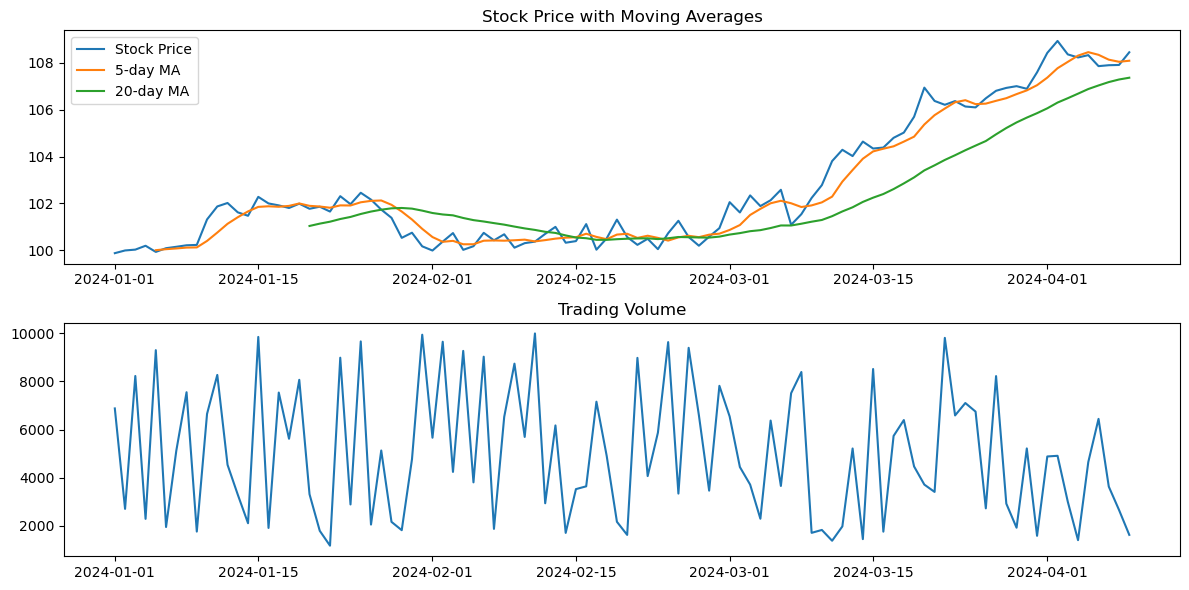

Time series plots created successfully!


In [66]:
# Create time series data
dates = pd.date_range('2024-01-01', periods=100, freq='D')
ts_data = {
    'Date': dates,
    'Stock_Price': 100 + np.cumsum(np.random.randn(100) * 0.5),
    'Volume': np.random.randint(1000, 10000, 100),
    'High': 100 + np.cumsum(np.random.randn(100) * 0.5) + np.random.rand(100) * 2,
    'Low': 100 + np.cumsum(np.random.randn(100) * 0.5) - np.random.rand(100) * 2
}

ts_df = pd.DataFrame(ts_data)
ts_df.set_index('Date', inplace=True)

print(f"Time Series DataFrame:\n{ts_df.head(10)}")
print(f"\nDataFrame info:\n{ts_df.info()}")

# Basic time series operations
print(f"\n--- Basic Time Series Operations ---")

# Date range operations
print(f"Date range: {ts_df.index.min()} to {ts_df.index.max()}")
print(f"Number of days: {len(ts_df)}")

# Time-based indexing
print(f"\n--- Time-based Indexing ---")
print(f"January 2024 data:\n{ts_df.loc['2024-01'].head()}")
print(f"First week data:\n{ts_df['2024-01-01':'2024-01-07']}")

# Resampling
print(f"\n--- Resampling ---")
# Daily to weekly
weekly_data = ts_df.resample('W').agg({
    'Stock_Price': 'last',
    'Volume': 'sum',
    'High': 'max',
    'Low': 'min'
})
print(f"Weekly data:\n{weekly_data.head()}")

# Daily to monthly
monthly_data = ts_df.resample('M').agg({
    'Stock_Price': 'last',
    'Volume': 'sum',
    'High': 'max',
    'Low': 'min'
})
print(f"Monthly data:\n{monthly_data.head()}")

# Time shifting
print(f"\n--- Time Shifting ---")
ts_df['Price_1Day_Lag'] = ts_df['Stock_Price'].shift(1)
ts_df['Price_1Day_Lead'] = ts_df['Stock_Price'].shift(-1)
ts_df['Price_1Week_Lag'] = ts_df['Stock_Price'].shift(7)

print(f"Time shifted data:\n{ts_df[['Stock_Price', 'Price_1Day_Lag', 'Price_1Day_Lead', 'Price_1Week_Lag']].head(10)}")

# Time differences
print(f"\n--- Time Differences ---")
ts_df['Price_Change'] = ts_df['Stock_Price'].diff()
ts_df['Price_Pct_Change'] = ts_df['Stock_Price'].pct_change()
ts_df['Price_Change_1Week'] = ts_df['Stock_Price'].diff(7)

print(f"Price changes:\n{ts_df[['Stock_Price', 'Price_Change', 'Price_Pct_Change', 'Price_Change_1Week']].head(10)}")

# Rolling operations
print(f"\n--- Rolling Operations ---")
ts_df['Price_MA_5'] = ts_df['Stock_Price'].rolling(window=5).mean()
ts_df['Price_MA_20'] = ts_df['Stock_Price'].rolling(window=20).mean()
ts_df['Price_Std_10'] = ts_df['Stock_Price'].rolling(window=10).std()
ts_df['Price_Max_7'] = ts_df['Stock_Price'].rolling(window=7).max()
ts_df['Price_Min_7'] = ts_df['Stock_Price'].rolling(window=7).min()

print(f"Rolling statistics:\n{ts_df[['Stock_Price', 'Price_MA_5', 'Price_MA_20', 'Price_Std_10']].head(10)}")

# Expanding operations
print(f"\n--- Expanding Operations ---")
ts_df['Price_Expanding_Mean'] = ts_df['Stock_Price'].expanding().mean()
ts_df['Price_Expanding_Std'] = ts_df['Stock_Price'].expanding().std()
ts_df['Price_Expanding_Max'] = ts_df['Stock_Price'].expanding().max()

print(f"Expanding statistics:\n{ts_df[['Stock_Price', 'Price_Expanding_Mean', 'Price_Expanding_Std', 'Price_Expanding_Max']].head(10)}")

# Time series decomposition
print(f"\n--- Time Series Decomposition ---")
from statsmodels.tsa.seasonal import seasonal_decompose

# Create a more realistic time series with trend and seasonality
np.random.seed(42)
t = np.arange(100)
trend = 0.1 * t
seasonal = 2 * np.sin(2 * np.pi * t / 7)  # Weekly seasonality
noise = np.random.randn(100) * 0.5
ts_values = 100 + trend + seasonal + noise

ts_decomp = pd.DataFrame({
    'Date': dates,
    'Value': ts_values
}).set_index('Date')

# Decompose the time series
decomposition = seasonal_decompose(ts_decomp['Value'], model='additive', period=7)
print(f"Decomposition components:\n{decomposition.trend.head()}")
print(f"Seasonal component:\n{decomposition.seasonal.head()}")
print(f"Residual component:\n{decomposition.resid.head()}")

# Time series frequency conversion
print(f"\n--- Frequency Conversion ---")
# Convert daily to business days
business_days = ts_df.asfreq('B')  # Business days
print(f"Business days data:\n{business_days.head()}")

# Convert to hourly (with forward fill)
hourly_data = ts_df.asfreq('H', method='ffill')
print(f"Hourly data (first 24 hours):\n{hourly_data.head(24)}")

# Time zone operations
print(f"\n--- Time Zone Operations ---")
# Create timezone-aware data
ts_df_tz = ts_df.copy()
ts_df_tz.index = ts_df_tz.index.tz_localize('UTC')
print(f"UTC timezone data:\n{ts_df_tz.head()}")

# Convert to different timezone
ts_df_est = ts_df_tz.tz_convert('US/Eastern')
print(f"EST timezone data:\n{ts_df_est.head()}")

# Time series interpolation
print(f"\n--- Time Series Interpolation ---")
# Create data with missing values
ts_missing = ts_df.copy()
ts_missing.loc[ts_missing.index[10:15], 'Stock_Price'] = np.nan
ts_missing.loc[ts_missing.index[30:35], 'Stock_Price'] = np.nan

print(f"Data with missing values:\n{ts_missing[['Stock_Price']].head(40)}")

# Interpolate missing values
ts_interpolated = ts_missing.interpolate(method='linear')
print(f"Interpolated data:\n{ts_interpolated[['Stock_Price']].head(40)}")

# Different interpolation methods
ts_spline = ts_missing.interpolate(method='spline', order=2)
ts_polynomial = ts_missing.interpolate(method='polynomial', order=2)

print(f"Spline interpolation:\n{ts_spline[['Stock_Price']].head(40)}")

# Time series aggregation
print(f"\n--- Time Series Aggregation ---")
# Group by time periods
ts_df['Year'] = ts_df.index.year
ts_df['Month'] = ts_df.index.month
ts_df['DayOfWeek'] = ts_df.index.dayofweek
ts_df['Quarter'] = ts_df.index.quarter

# Aggregate by year
yearly_agg = ts_df.groupby('Year').agg({
    'Stock_Price': ['mean', 'std', 'min', 'max'],
    'Volume': 'sum'
})
print(f"Yearly aggregation:\n{yearly_agg}")

# Aggregate by quarter
quarterly_agg = ts_df.groupby('Quarter').agg({
    'Stock_Price': 'mean',
    'Volume': 'sum'
})
print(f"Quarterly aggregation:\n{quarterly_agg}")

# Aggregate by day of week
dow_agg = ts_df.groupby('DayOfWeek').agg({
    'Stock_Price': 'mean',
    'Volume': 'mean'
})
print(f"Day of week aggregation:\n{dow_agg}")

# Time series plotting
print(f"\n--- Time Series Plotting ---")
import matplotlib.pyplot as plt

# Create a simple plot
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(ts_df.index, ts_df['Stock_Price'], label='Stock Price')
plt.plot(ts_df.index, ts_df['Price_MA_5'], label='5-day MA')
plt.plot(ts_df.index, ts_df['Price_MA_20'], label='20-day MA')
plt.title('Stock Price with Moving Averages')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(ts_df.index, ts_df['Volume'])
plt.title('Trading Volume')
plt.tight_layout()
plt.show()

print("Time series plots created successfully!")


## 7. Window Functions and Rolling Operations


In [ ]:
# Create sample data for window functions
np.random.seed(42)
window_data = {
    'Date': pd.date_range('2024-01-01', periods=50, freq='D'),
    'Stock_Price': 100 + np.cumsum(np.random.randn(50) * 0.5),
    'Volume': np.random.randint(1000, 10000, 50),
    'Company': ['AAPL'] * 25 + ['GOOGL'] * 25
}

window_df = pd.DataFrame(window_data)
window_df.set_index('Date', inplace=True)

print(f"Window Functions DataFrame:\n{window_df.head(10)}")

# Basic rolling operations
print(f"\n--- Basic Rolling Operations ---")

# Rolling mean
window_df['Price_MA_5'] = window_df['Stock_Price'].rolling(window=5).mean()
window_df['Price_MA_10'] = window_df['Stock_Price'].rolling(window=10).mean()
window_df['Price_MA_20'] = window_df['Stock_Price'].rolling(window=20).mean()

print(f"Rolling means:\n{window_df[['Stock_Price', 'Price_MA_5', 'Price_MA_10', 'Price_MA_20']].head(15)}")

# Rolling standard deviation
window_df['Price_Std_5'] = window_df['Stock_Price'].rolling(window=5).std()
window_df['Price_Std_10'] = window_df['Stock_Price'].rolling(window=10).std()

print(f"Rolling standard deviations:\n{window_df[['Stock_Price', 'Price_Std_5', 'Price_Std_10']].head(15)}")

# Rolling min/max
window_df['Price_Min_5'] = window_df['Stock_Price'].rolling(window=5).min()
window_df['Price_Max_5'] = window_df['Stock_Price'].rolling(window=5).max()
window_df['Price_Range_5'] = window_df['Price_Max_5'] - window_df['Price_Min_5']

print(f"Rolling min/max:\n{window_df[['Stock_Price', 'Price_Min_5', 'Price_Max_5', 'Price_Range_5']].head(15)}")

# Rolling sum
window_df['Volume_Sum_5'] = window_df['Volume'].rolling(window=5).sum()
window_df['Volume_Sum_10'] = window_df['Volume'].rolling(window=10).sum()

print(f"Rolling volume sums:\n{window_df[['Volume', 'Volume_Sum_5', 'Volume_Sum_10']].head(15)}")

# Rolling quantiles
window_df['Price_Q25_10'] = window_df['Stock_Price'].rolling(window=10).quantile(0.25)
window_df['Price_Q75_10'] = window_df['Stock_Price'].rolling(window=10).quantile(0.75)
window_df['Price_IQR_10'] = window_df['Price_Q75_10'] - window_df['Price_Q25_10']

print(f"Rolling quantiles:\n{window_df[['Stock_Price', 'Price_Q25_10', 'Price_Q75_10', 'Price_IQR_10']].head(15)}")

# Rolling apply with custom functions
print(f"\n--- Rolling Apply with Custom Functions ---")

def custom_volatility(series):
    return series.std() / series.mean()

def custom_skewness(series):
    return series.skew()

def custom_kurtosis(series):
    return series.kurtosis()

window_df['Price_Volatility_10'] = window_df['Stock_Price'].rolling(window=10).apply(custom_volatility)
window_df['Price_Skewness_10'] = window_df['Stock_Price'].rolling(window=10).apply(custom_skewness)
window_df['Price_Kurtosis_10'] = window_df['Stock_Price'].rolling(window=10).apply(custom_kurtosis)

print(f"Custom rolling functions:\n{window_df[['Stock_Price', 'Price_Volatility_10', 'Price_Skewness_10', 'Price_Kurtosis_10']].head(15)}")

# Rolling window with different alignments
print(f"\n--- Rolling Window Alignments ---")

# Center alignment (default)
window_df['Price_MA_Center'] = window_df['Stock_Price'].rolling(window=5, center=True).mean()

# Right alignment
window_df['Price_MA_Right'] = window_df['Stock_Price'].rolling(window=5, center=False).mean()

# Left alignment
window_df['Price_MA_Left'] = window_df['Stock_Price'].rolling(window=5, center=False, min_periods=1).mean()

print(f"Different alignments:\n{window_df[['Stock_Price', 'Price_MA_Center', 'Price_MA_Right', 'Price_MA_Left']].head(15)}")

# Expanding operations
print(f"\n--- Expanding Operations ---")

# Expanding mean
window_df['Price_Exp_Mean'] = window_df['Stock_Price'].expanding().mean()
window_df['Price_Exp_Std'] = window_df['Stock_Price'].expanding().std()
window_df['Price_Exp_Min'] = window_df['Stock_Price'].expanding().min()
window_df['Price_Exp_Max'] = window_df['Stock_Price'].expanding().max()

print(f"Expanding operations:\n{window_df[['Stock_Price', 'Price_Exp_Mean', 'Price_Exp_Std', 'Price_Exp_Min', 'Price_Exp_Max']].head(15)}")

# Expanding with custom functions
window_df['Price_Exp_Volatility'] = window_df['Stock_Price'].expanding().apply(custom_volatility)
window_df['Price_Exp_Skewness'] = window_df['Stock_Price'].expanding().apply(custom_skewness)

print(f"Expanding custom functions:\n{window_df[['Stock_Price', 'Price_Exp_Volatility', 'Price_Exp_Skewness']].head(15)}")

# Exponentially weighted operations
print(f"\n--- Exponentially Weighted Operations ---")

# Exponentially weighted mean
window_df['Price_EWM_5'] = window_df['Stock_Price'].ewm(span=5).mean()
window_df['Price_EWM_10'] = window_df['Stock_Price'].ewm(span=10).mean()
window_df['Price_EWM_20'] = window_df['Stock_Price'].ewm(span=20).mean()

print(f"Exponentially weighted means:\n{window_df[['Stock_Price', 'Price_EWM_5', 'Price_EWM_10', 'Price_EWM_20']].head(15)}")

# Exponentially weighted standard deviation
window_df['Price_EWM_Std_10'] = window_df['Stock_Price'].ewm(span=10).std()
window_df['Price_EWM_Var_10'] = window_df['Stock_Price'].ewm(span=10).var()

print(f"Exponentially weighted std/var:\n{window_df[['Stock_Price', 'Price_EWM_Std_10', 'Price_EWM_Var_10']].head(15)}")

# Exponentially weighted with different halflife
window_df['Price_EWM_HL_5'] = window_df['Stock_Price'].ewm(halflife=5).mean()
window_df['Price_EWM_HL_10'] = window_df['Stock_Price'].ewm(halflife=10).mean()

print(f"Exponentially weighted with halflife:\n{window_df[['Stock_Price', 'Price_EWM_HL_5', 'Price_EWM_HL_10']].head(15)}")

# Rolling window with groupby
print(f"\n--- Rolling Window with GroupBy ---")

# Group by company and apply rolling operations
window_df['Price_MA_5_Grouped'] = window_df.groupby('Company')['Stock_Price'].rolling(window=5).mean().reset_index(0, drop=True)
window_df['Price_Std_5_Grouped'] = window_df.groupby('Company')['Stock_Price'].rolling(window=5).std().reset_index(0, drop=True)

print(f"Grouped rolling operations:\n{window_df[['Company', 'Stock_Price', 'Price_MA_5_Grouped', 'Price_Std_5_Grouped']].head(15)}")

# Rolling window with time-based windows
print(f"\n--- Time-based Rolling Windows ---")

# Rolling window based on time periods
window_df['Price_MA_7D'] = window_df['Stock_Price'].rolling(window='7D').mean()
window_df['Price_MA_14D'] = window_df['Stock_Price'].rolling(window='14D').mean()
window_df['Price_MA_30D'] = window_df['Stock_Price'].rolling(window='30D').mean()

print(f"Time-based rolling means:\n{window_df[['Stock_Price', 'Price_MA_7D', 'Price_MA_14D', 'Price_MA_30D']].head(15)}")

# Rolling window with business days
window_df['Price_MA_5B'] = window_df['Stock_Price'].rolling(window='5B').mean()
window_df['Price_MA_10B'] = window_df['Stock_Price'].rolling(window='10B').mean()

print(f"Business day rolling means:\n{window_df[['Stock_Price', 'Price_MA_5B', 'Price_MA_10B']].head(15)}")

# Rolling window with custom offsets
print(f"\n--- Custom Offset Rolling Windows ---")

# Rolling window with custom offset
window_df['Price_MA_Custom'] = window_df['Stock_Price'].rolling(window=pd.Timedelta(days=7)).mean()
window_df['Price_MA_Custom_2W'] = window_df['Stock_Price'].rolling(window=pd.Timedelta(weeks=2)).mean()

print(f"Custom offset rolling means:\n{window_df[['Stock_Price', 'Price_MA_Custom', 'Price_MA_Custom_2W']].head(15)}")

# Rolling window with min_periods
print(f"\n--- Rolling Window with min_periods ---")

# Rolling mean with minimum periods
window_df['Price_MA_Min3'] = window_df['Stock_Price'].rolling(window=5, min_periods=3).mean()
window_df['Price_MA_Min1'] = window_df['Stock_Price'].rolling(window=5, min_periods=1).mean()

print(f"Rolling means with min_periods:\n{window_df[['Stock_Price', 'Price_MA_Min3', 'Price_MA_Min1']].head(15)}")

# Rolling window with different aggregation functions
print(f"\n--- Rolling Window Aggregations ---")

# Multiple aggregations in one call
rolling_agg = window_df['Stock_Price'].rolling(window=10).agg(['mean', 'std', 'min', 'max', 'count'])
print(f"Rolling aggregations:\n{rolling_agg.head(15)}")

# Rolling window with custom aggregation
def custom_agg(series):
    return {
        'mean': series.mean(),
        'std': series.std(),
        'range': series.max() - series.min(),
        'volatility': series.std() / series.mean()
    }

rolling_custom = window_df['Stock_Price'].rolling(window=10).apply(lambda x: custom_agg(x)['volatility'])
print(f"Custom rolling aggregation:\n{rolling_custom.head(15)}")

# Rolling window with different data types
print(f"\n--- Rolling Window with Different Data Types ---")

# Rolling count of non-null values
window_df['Volume_Count_5'] = window_df['Volume'].rolling(window=5).count()
window_df['Volume_Count_10'] = window_df['Volume'].rolling(window=10).count()

# Rolling sum
window_df['Volume_Sum_5'] = window_df['Volume'].rolling(window=5).sum()
window_df['Volume_Sum_10'] = window_df['Volume'].rolling(window=10).sum()

# Rolling mean
window_df['Volume_Mean_5'] = window_df['Volume'].rolling(window=5).mean()
window_df['Volume_Mean_10'] = window_df['Volume'].rolling(window=10).mean()

print(f"Volume rolling operations:\n{window_df[['Volume', 'Volume_Count_5', 'Volume_Sum_5', 'Volume_Mean_5']].head(15)}")

# Rolling window with missing data handling
print(f"\n--- Rolling Window with Missing Data ---")

# Create data with missing values
window_missing = window_df.copy()
window_missing.loc[window_missing.index[10:15], 'Stock_Price'] = np.nan
window_missing.loc[window_missing.index[25:30], 'Stock_Price'] = np.nan

# Rolling mean with different missing data handling
window_missing['Price_MA_5_Default'] = window_missing['Stock_Price'].rolling(window=5).mean()
window_missing['Price_MA_5_Min3'] = window_missing['Stock_Price'].rolling(window=5, min_periods=3).mean()
window_missing['Price_MA_5_Min1'] = window_missing['Stock_Price'].rolling(window=5, min_periods=1).mean()

print(f"Rolling with missing data:\n{window_missing[['Stock_Price', 'Price_MA_5_Default', 'Price_MA_5_Min3', 'Price_MA_5_Min1']].head(35)}")

# Rolling window performance comparison
print(f"\n--- Rolling Window Performance ---")
import time

# Large dataset for performance testing
large_data = pd.DataFrame({
    'Date': pd.date_range('2020-01-01', periods=1000, freq='D'),
    'Price': 100 + np.cumsum(np.random.randn(1000) * 0.5)
}).set_index('Date')

# Time different rolling operations
start_time = time.time()
large_data['MA_5'] = large_data['Price'].rolling(window=5).mean()
end_time = time.time()
print(f"Rolling mean (5): {end_time - start_time:.4f} seconds")

start_time = time.time()
large_data['MA_20'] = large_data['Price'].rolling(window=20).mean()
end_time = time.time()
print(f"Rolling mean (20): {end_time - start_time:.4f} seconds")

start_time = time.time()
large_data['EWM_10'] = large_data['Price'].ewm(span=10).mean()
end_time = time.time()
print(f"Exponentially weighted mean: {end_time - start_time:.4f} seconds")

print(f"Large dataset shape: {large_data.shape}")
print(f"Sample results:\n{large_data[['Price', 'MA_5', 'MA_20', 'EWM_10']].head(10)}")

print("\nWindow functions and rolling operations completed successfully!")


## 8. Advanced Filtering and Querying


In [ ]:
# Create comprehensive dataset for advanced filtering
np.random.seed(42)
filter_data = {
    'Employee_ID': range(1, 101),
    'Name': [f'Employee_{i}' for i in range(1, 101)],
    'Department': np.random.choice(['IT', 'HR', 'Finance', 'Marketing', 'Sales'], 100),
    'Salary': np.random.normal(60000, 15000, 100).astype(int),
    'Experience': np.random.randint(1, 25, 100),
    'Performance': np.random.choice(['Excellent', 'Good', 'Average', 'Poor'], 100),
    'Location': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'], 100),
    'Age': np.random.randint(22, 65, 100),
    'Bonus': np.random.normal(5000, 2000, 100).astype(int),
    'Start_Date': pd.date_range('2020-01-01', periods=100, freq='D')
}

filter_df = pd.DataFrame(filter_data)
print(f"Filtering DataFrame:\n{filter_df.head(10)}")
print(f"\nDataFrame shape: {filter_df.shape}")

# Basic filtering with boolean indexing
print(f"\n--- Basic Boolean Indexing ---")

# Simple conditions
high_salary = filter_df[filter_df['Salary'] > 70000]
print(f"High salary employees (>70k): {len(high_salary)}")
print(f"Sample high salary employees:\n{high_salary[['Name', 'Department', 'Salary']].head()}")

# Multiple conditions with AND (&)
it_high_salary = filter_df[(filter_df['Department'] == 'IT') & (filter_df['Salary'] > 70000)]
print(f"\nIT employees with high salary: {len(it_high_salary)}")
print(f"Sample IT high salary employees:\n{it_high_salary[['Name', 'Department', 'Salary']].head()}")

# Multiple conditions with OR (|)
it_or_finance = filter_df[(filter_df['Department'] == 'IT') | (filter_df['Department'] == 'Finance')]
print(f"\nIT or Finance employees: {len(it_or_finance)}")
print(f"Sample IT or Finance employees:\n{it_or_finance[['Name', 'Department', 'Salary']].head()}")

# Complex conditions with parentheses
complex_filter = filter_df[
    ((filter_df['Department'] == 'IT') | (filter_df['Department'] == 'Finance')) & 
    (filter_df['Salary'] > 60000) & 
    (filter_df['Experience'] > 5)
]
print(f"\nComplex filter (IT/Finance, >60k salary, >5 years exp): {len(complex_filter)}")
print(f"Sample complex filter results:\n{complex_filter[['Name', 'Department', 'Salary', 'Experience']].head()}")

# Using isin() for multiple values
print(f"\n--- Using isin() for Multiple Values ---")

# Filter by multiple departments
selected_depts = filter_df[filter_df['Department'].isin(['IT', 'HR', 'Finance'])]
print(f"Employees in IT, HR, or Finance: {len(selected_depts)}")

# Filter by multiple performance levels
good_performers = filter_df[filter_df['Performance'].isin(['Excellent', 'Good'])]
print(f"Good performers: {len(good_performers)}")

# Filter by multiple locations
major_cities = filter_df[filter_df['Location'].isin(['New York', 'Los Angeles', 'Chicago'])]
print(f"Employees in major cities: {len(major_cities)}")

# Using query() method
print(f"\n--- Using query() Method ---")

# Simple query
query_result1 = filter_df.query('Salary > 70000')
print(f"Query: Salary > 70000, Results: {len(query_result1)}")

# Complex query with multiple conditions
query_result2 = filter_df.query('Department == "IT" and Salary > 60000 and Experience > 5')
print(f"Query: IT department, >60k salary, >5 years exp, Results: {len(query_result2)}")

# Query with OR conditions
query_result3 = filter_df.query('Department in ["IT", "Finance"] and Salary > 50000')
print(f"Query: IT or Finance, >50k salary, Results: {len(query_result3)}")

# Query with string methods
query_result4 = filter_df.query('Name.str.contains("Employee_1")')
print(f"Query: Name contains 'Employee_1', Results: {len(query_result4)}")

# Query with date filtering
query_result5 = filter_df.query('Start_Date >= "2020-06-01"')
print(f"Query: Started after June 2020, Results: {len(query_result5)}")

# Advanced string filtering
print(f"\n--- Advanced String Filtering ---")

# Using str.contains()
names_with_1 = filter_df[filter_df['Name'].str.contains('Employee_1')]
print(f"Names containing 'Employee_1': {len(names_with_1)}")

# Using str.startswith()
names_starting_with = filter_df[filter_df['Name'].str.startswith('Employee_1')]
print(f"Names starting with 'Employee_1': {len(names_starting_with)}")

# Using str.endswith()
names_ending_with = filter_df[filter_df['Name'].str.endswith('0')]
print(f"Names ending with '0': {len(names_ending_with)}")

# Using str.match() with regex
names_matching = filter_df[filter_df['Name'].str.match(r'Employee_[1-5]\d')]
print(f"Names matching pattern 'Employee_[1-5]\\d': {len(names_matching)}")

# Case-insensitive string filtering
names_case_insensitive = filter_df[filter_df['Name'].str.contains('employee', case=False)]
print(f"Names containing 'employee' (case-insensitive): {len(names_case_insensitive)}")

# Numeric filtering with ranges
print(f"\n--- Numeric Filtering with Ranges ---")

# Using between()
salary_range = filter_df[filter_df['Salary'].between(50000, 70000)]
print(f"Salary between 50k-70k: {len(salary_range)}")

# Using multiple between conditions
age_salary_range = filter_df[
    filter_df['Age'].between(30, 50) & 
    filter_df['Salary'].between(60000, 80000)
]
print(f"Age 30-50 and salary 60k-80k: {len(age_salary_range)}")

# Using quantile-based filtering
salary_75th = filter_df['Salary'].quantile(0.75)
high_earners = filter_df[filter_df['Salary'] > salary_75th]
print(f"Top 25% earners (>{salary_75th:.0f}): {len(high_earners)}")

# Using percentile-based filtering
salary_90th = filter_df['Salary'].quantile(0.9)
top_earners = filter_df[filter_df['Salary'] > salary_90th]
print(f"Top 10% earners (>{salary_90th:.0f}): {len(top_earners)}")

# Date filtering
print(f"\n--- Date Filtering ---")

# Filter by year
employees_2020 = filter_df[filter_df['Start_Date'].dt.year == 2020]
print(f"Employees who started in 2020: {len(employees_2020)}")

# Filter by month
employees_jan = filter_df[filter_df['Start_Date'].dt.month == 1]
print(f"Employees who started in January: {len(employees_jan)}")

# Filter by date range
date_range = filter_df[
    (filter_df['Start_Date'] >= '2020-06-01') & 
    (filter_df['Start_Date'] <= '2020-12-31')
]
print(f"Employees who started in H2 2020: {len(date_range)}")

# Filter by day of week
employees_monday = filter_df[filter_df['Start_Date'].dt.dayofweek == 0]
print(f"Employees who started on Monday: {len(employees_monday)}")

# Filter by quarter
employees_q1 = filter_df[filter_df['Start_Date'].dt.quarter == 1]
print(f"Employees who started in Q1: {len(employees_q1)}")

# Null value filtering
print(f"\n--- Null Value Filtering ---")

# Create data with null values
filter_df_with_nulls = filter_df.copy()
filter_df_with_nulls.loc[filter_df_with_nulls.index[10:15], 'Bonus'] = np.nan
filter_df_with_nulls.loc[filter_df_with_nulls.index[20:25], 'Experience'] = np.nan

# Filter non-null values
non_null_bonus = filter_df_with_nulls[filter_df_with_nulls['Bonus'].notna()]
print(f"Employees with non-null bonus: {len(non_null_bonus)}")

# Filter null values
null_bonus = filter_df_with_nulls[filter_df_with_nulls['Bonus'].isna()]
print(f"Employees with null bonus: {len(null_bonus)}")

# Filter multiple columns for nulls
any_null = filter_df_with_nulls[filter_df_with_nulls[['Bonus', 'Experience']].isna().any(axis=1)]
print(f"Employees with any null in Bonus or Experience: {len(any_null)}")

# Filter all columns for nulls
all_null = filter_df_with_nulls[filter_df_with_nulls[['Bonus', 'Experience']].isna().all(axis=1)]
print(f"Employees with all null in Bonus and Experience: {len(all_null)}")

# Advanced filtering with custom functions
print(f"\n--- Advanced Filtering with Custom Functions ---")

# Filter with custom function
def is_senior_employee(row):
    return row['Experience'] > 10 and row['Salary'] > 70000

senior_employees = filter_df[filter_df.apply(is_senior_employee, axis=1)]
print(f"Senior employees (custom function): {len(senior_employees)}")

# Filter with lambda function
young_high_earners = filter_df[filter_df.apply(lambda x: x['Age'] < 30 and x['Salary'] > 60000, axis=1)]
print(f"Young high earners (lambda): {len(young_high_earners)}")

# Filter with multiple custom conditions
def complex_filter_func(row):
    return (
        row['Department'] in ['IT', 'Finance'] and
        row['Salary'] > 60000 and
        row['Experience'] > 5 and
        row['Performance'] in ['Excellent', 'Good']
    )

complex_filtered = filter_df[filter_df.apply(complex_filter_func, axis=1)]
print(f"Complex filtered employees: {len(complex_filtered)}")

# Using where() method
print(f"\n--- Using where() Method ---")

# where() with condition
salary_where = filter_df.where(filter_df['Salary'] > 70000)
print(f"where() method - high salary employees:\n{salary_where[['Name', 'Department', 'Salary']].dropna().head()}")

# where() with multiple conditions
complex_where = filter_df.where(
    (filter_df['Department'] == 'IT') & (filter_df['Salary'] > 60000)
)
print(f"where() method - IT high salary:\n{complex_where[['Name', 'Department', 'Salary']].dropna().head()}")

# Using mask() method (opposite of where)
print(f"\n--- Using mask() Method ---")

# mask() with condition
salary_mask = filter_df.mask(filter_df['Salary'] <= 70000)
print(f"mask() method - high salary employees:\n{salary_mask[['Name', 'Department', 'Salary']].dropna().head()}")

# Performance comparison
print(f"\n--- Performance Comparison ---")
import time

# Large dataset for performance testing
large_filter_data = {
    'ID': range(1, 10001),
    'Value': np.random.randn(10000),
    'Category': np.random.choice(['A', 'B', 'C', 'D', 'E'], 10000),
    'Score': np.random.randint(0, 100, 10000)
}
large_filter_df = pd.DataFrame(large_filter_data)

# Time different filtering methods
start_time = time.time()
result1 = large_filter_df[large_filter_df['Value'] > 0]
end_time = time.time()
print(f"Boolean indexing time: {end_time - start_time:.4f} seconds")

start_time = time.time()
result2 = large_filter_df.query('Value > 0')
end_time = time.time()
print(f"query() method time: {end_time - start_time:.4f} seconds")

start_time = time.time()
result3 = large_filter_df[large_filter_df.apply(lambda x: x['Value'] > 0, axis=1)]
end_time = time.time()
print(f"apply() method time: {end_time - start_time:.4f} seconds")

print(f"All methods produced same result: {len(result1) == len(result2) == len(result3)}")

# Advanced query examples
print(f"\n--- Advanced Query Examples ---")

# Query with mathematical operations
math_query = filter_df.query('Salary * 1.1 > 70000')
print(f"Salary * 1.1 > 70000: {len(math_query)}")

# Query with string operations
string_query = filter_df.query('Name.str.len() > 10')
print(f"Name length > 10: {len(string_query)}")

# Query with date operations
date_query = filter_df.query('Start_Date.dt.year == 2020 and Start_Date.dt.month >= 6')
print(f"Started in H2 2020: {len(date_query)}")

# Query with multiple conditions and parentheses
complex_query = filter_df.query(
    '(Department == "IT" or Department == "Finance") and '
    'Salary > 60000 and '
    'Experience > 5 and '
    'Performance in ["Excellent", "Good"]'
)
print(f"Complex query results: {len(complex_query)}")

print("\nAdvanced filtering and querying completed successfully!")


## 9. Multi-level Indexing


In [ ]:
# Create data for multi-level indexing examples
np.random.seed(42)
multi_data = {
    'Company': ['Apple', 'Apple', 'Apple', 'Apple', 'Google', 'Google', 'Google', 'Google', 'Microsoft', 'Microsoft', 'Microsoft', 'Microsoft'],
    'Year': [2020, 2020, 2021, 2021, 2020, 2020, 2021, 2021, 2020, 2020, 2021, 2021],
    'Quarter': ['Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2'],
    'Revenue': [58000, 62000, 65000, 68000, 45000, 48000, 52000, 55000, 38000, 41000, 44000, 47000],
    'Profit': [12000, 14000, 15000, 16000, 8000, 9000, 10000, 11000, 6000, 7000, 8000, 9000],
    'Employees': [150000, 155000, 160000, 165000, 120000, 125000, 130000, 135000, 180000, 185000, 190000, 195000]
}

multi_df = pd.DataFrame(multi_data)
print(f"Original DataFrame:\n{multi_df}")

# Create MultiIndex from columns
print(f"\n--- Creating MultiIndex from Columns ---")

# Set multiple columns as index
multi_indexed = multi_df.set_index(['Company', 'Year', 'Quarter'])
print(f"MultiIndexed DataFrame:\n{multi_indexed}")

# Create MultiIndex from tuples
print(f"\n--- Creating MultiIndex from Tuples ---")

# Create MultiIndex from tuples
tuples = [('Apple', 2020), ('Apple', 2021), ('Google', 2020), ('Google', 2021), ('Microsoft', 2020), ('Microsoft', 2021)]
multi_index = pd.MultiIndex.from_tuples(tuples, names=['Company', 'Year'])
print(f"MultiIndex from tuples:\n{multi_index}")

# Create DataFrame with MultiIndex
multi_df_tuples = pd.DataFrame({
    'Q1_Revenue': [58000, 65000, 45000, 52000, 38000, 44000],
    'Q2_Revenue': [62000, 68000, 48000, 55000, 41000, 47000],
    'Q1_Profit': [12000, 15000, 8000, 10000, 6000, 8000],
    'Q2_Profit': [14000, 16000, 9000, 11000, 7000, 9000]
}, index=multi_index)
print(f"DataFrame with MultiIndex from tuples:\n{multi_df_tuples}")

# Create MultiIndex from arrays
print(f"\n--- Creating MultiIndex from Arrays ---")

# Create MultiIndex from arrays
companies = ['Apple', 'Apple', 'Google', 'Google', 'Microsoft', 'Microsoft']
years = [2020, 2021, 2020, 2021, 2020, 2021]
multi_index_arrays = pd.MultiIndex.from_arrays([companies, years], names=['Company', 'Year'])
print(f"MultiIndex from arrays:\n{multi_index_arrays}")

# Create MultiIndex from product
print(f"\n--- Creating MultiIndex from Product ---")

# Create MultiIndex from product
companies = ['Apple', 'Google', 'Microsoft']
years = [2020, 2021]
quarters = ['Q1', 'Q2']
multi_index_product = pd.MultiIndex.from_product([companies, years, quarters], names=['Company', 'Year', 'Quarter'])
print(f"MultiIndex from product:\n{multi_index_product}")

# Indexing with MultiIndex
print(f"\n--- Indexing with MultiIndex ---")

# Access by first level
apple_data = multi_indexed.loc['Apple']
print(f"Apple data:\n{apple_data}")

# Access by multiple levels
apple_2020 = multi_indexed.loc[('Apple', 2020)]
print(f"Apple 2020 data:\n{apple_2020}")

# Access by all levels
apple_2020_q1 = multi_indexed.loc[('Apple', 2020, 'Q1')]
print(f"Apple 2020 Q1 data:\n{apple_2020_q1}")

# Slicing with MultiIndex
print(f"\n--- Slicing with MultiIndex ---")

# Slice by first level
apple_google = multi_indexed.loc[['Apple', 'Google']]
print(f"Apple and Google data:\n{apple_google}")

# Slice by multiple levels
apple_2020_2021 = multi_indexed.loc[('Apple', [2020, 2021])]
print(f"Apple 2020-2021 data:\n{apple_2020_2021}")

# Slice by all levels
apple_2020_q1_q2 = multi_indexed.loc[('Apple', 2020, ['Q1', 'Q2'])]
print(f"Apple 2020 Q1-Q2 data:\n{apple_2020_q1_q2}")

# Cross-section selection
print(f"\n--- Cross-section Selection ---")

# Select all data for 2020
data_2020 = multi_indexed.xs(2020, level='Year')
print(f"All data for 2020:\n{data_2020}")

# Select all data for Q1
data_q1 = multi_indexed.xs('Q1', level='Quarter')
print(f"All data for Q1:\n{data_q1}")

# Select Apple data for Q1
apple_q1 = multi_indexed.xs(('Apple', 'Q1'), level=['Company', 'Quarter'])
print(f"Apple data for Q1:\n{apple_q1}")

# Select specific company and year
apple_2020_xs = multi_indexed.xs(('Apple', 2020), level=['Company', 'Year'])
print(f"Apple 2020 data (xs):\n{apple_2020_xs}")

# MultiIndex operations
print(f"\n--- MultiIndex Operations ---")

# Sort by index
sorted_multi = multi_indexed.sort_index()
print(f"Sorted by index:\n{sorted_multi}")

# Sort by specific level
sorted_by_year = multi_indexed.sort_index(level='Year')
print(f"Sorted by Year:\n{sorted_by_year}")

# Sort by multiple levels
sorted_by_company_year = multi_indexed.sort_index(level=['Company', 'Year'])
print(f"Sorted by Company and Year:\n{sorted_by_company_year}")

# Swap levels
swapped_levels = multi_indexed.swaplevel('Year', 'Quarter')
print(f"Swapped levels (Year, Quarter):\n{swapped_levels}")

# Reorder levels
reordered_levels = multi_indexed.reorder_levels(['Year', 'Company', 'Quarter'])
print(f"Reordered levels (Year, Company, Quarter):\n{reordered_levels}")

# Drop levels
dropped_level = multi_indexed.droplevel('Quarter')
print(f"Dropped Quarter level:\n{dropped_level}")

# Groupby with MultiIndex
print(f"\n--- Groupby with MultiIndex ---")

# Group by first level
grouped_company = multi_indexed.groupby(level='Company').sum()
print(f"Grouped by Company:\n{grouped_company}")

# Group by multiple levels
grouped_company_year = multi_indexed.groupby(level=['Company', 'Year']).sum()
print(f"Grouped by Company and Year:\n{grouped_company_year}")

# Group by specific level
grouped_year = multi_indexed.groupby(level='Year').mean()
print(f"Grouped by Year (mean):\n{grouped_year}")

# Aggregation with MultiIndex
print(f"\n--- Aggregation with MultiIndex ---")

# Multiple aggregations
agg_results = multi_indexed.groupby(level='Company').agg({
    'Revenue': ['sum', 'mean', 'std'],
    'Profit': ['sum', 'mean'],
    'Employees': 'last'
})
print(f"Aggregation results:\n{agg_results}")

# Custom aggregation
def revenue_growth(series):
    return series.iloc[-1] - series.iloc[0]

growth_results = multi_indexed.groupby(level='Company')['Revenue'].apply(revenue_growth)
print(f"Revenue growth by company:\n{growth_results}")

# Pivot with MultiIndex
print(f"\n--- Pivot with MultiIndex ---")

# Reset index to use pivot
pivot_df = multi_indexed.reset_index()
print(f"Reset index for pivot:\n{pivot_df}")

# Pivot to create MultiIndex columns
pivoted = pivot_df.pivot(index=['Company', 'Year'], columns='Quarter', values='Revenue')
print(f"Pivoted with MultiIndex columns:\n{pivoted}")

# Pivot with multiple values
pivoted_multi = pivot_df.pivot(index=['Company', 'Year'], columns='Quarter', values=['Revenue', 'Profit'])
print(f"Pivoted with multiple values:\n{pivoted_multi}")

# Stack and unstack with MultiIndex
print(f"\n--- Stack and Unstack with MultiIndex ---")

# Unstack (convert index to columns)
unstacked = multi_indexed.unstack('Quarter')
print(f"Unstacked by Quarter:\n{unstacked}")

# Unstack multiple levels
unstacked_multi = multi_indexed.unstack(['Year', 'Quarter'])
print(f"Unstacked by Year and Quarter:\n{unstacked_multi}")

# Stack (convert columns to index)
stacked = unstacked.stack('Quarter')
print(f"Stacked back:\n{stacked}")

# Melt with MultiIndex
print(f"\n--- Melt with MultiIndex ---")

# Melt the pivoted data
melted = pivoted.reset_index().melt(
    id_vars=['Company', 'Year'],
    value_vars=['Q1', 'Q2'],
    var_name='Quarter',
    value_name='Revenue'
)
print(f"Melted data:\n{melted}")

# Set MultiIndex after melt
melted_multi = melted.set_index(['Company', 'Year', 'Quarter'])
print(f"Melted with MultiIndex:\n{melted_multi}")

# MultiIndex with different data types
print(f"\n--- MultiIndex with Different Data Types ---")

# Create MultiIndex with different data types
mixed_data = {
    'Category': ['Electronics', 'Electronics', 'Clothing', 'Clothing', 'Books', 'Books'],
    'Subcategory': ['Phones', 'Laptops', 'Shirts', 'Pants', 'Fiction', 'Non-Fiction'],
    'Price': [800, 1200, 50, 80, 15, 25],
    'Stock': [100, 50, 200, 150, 300, 250]
}

mixed_df = pd.DataFrame(mixed_data)
mixed_multi = mixed_df.set_index(['Category', 'Subcategory'])
print(f"Mixed data with MultiIndex:\n{mixed_multi}")

# Access mixed data
electronics = mixed_multi.loc['Electronics']
print(f"Electronics data:\n{electronics}")

phones = mixed_multi.loc[('Electronics', 'Phones')]
print(f"Phones data:\n{phones}")

# MultiIndex with time series
print(f"\n--- MultiIndex with Time Series ---")

# Create time series data with MultiIndex
dates = pd.date_range('2024-01-01', periods=12, freq='M')
time_data = {
    'Company': ['Apple'] * 12 + ['Google'] * 12,
    'Date': list(dates) * 2,
    'Revenue': np.random.randint(50000, 80000, 24),
    'Profit': np.random.randint(10000, 20000, 24)
}

time_df = pd.DataFrame(time_data)
time_multi = time_df.set_index(['Company', 'Date'])
print(f"Time series with MultiIndex:\n{time_multi.head(10)}")

# Time-based operations with MultiIndex
time_grouped = time_multi.groupby(level='Company').resample('Q', level='Date').sum()
print(f"Quarterly data by company:\n{time_grouped}")

# MultiIndex performance
print(f"\n--- MultiIndex Performance ---")
import time

# Create large MultiIndex dataset
large_companies = ['Company_' + str(i) for i in range(100)]
large_years = [2020, 2021, 2022, 2023]
large_quarters = ['Q1', 'Q2', 'Q3', 'Q4']

large_multi_index = pd.MultiIndex.from_product(
    [large_companies, large_years, large_quarters],
    names=['Company', 'Year', 'Quarter']
)

large_data = pd.DataFrame({
    'Revenue': np.random.randint(10000, 100000, len(large_multi_index)),
    'Profit': np.random.randint(1000, 10000, len(large_multi_index))
}, index=large_multi_index)

print(f"Large MultiIndex dataset shape: {large_data.shape}")

# Time different operations
start_time = time.time()
result1 = large_data.loc['Company_0']
end_time = time.time()
print(f"Access by first level: {end_time - start_time:.4f} seconds")

start_time = time.time()
result2 = large_data.xs(2020, level='Year')
end_time = time.time()
print(f"Cross-section selection: {end_time - start_time:.4f} seconds")

start_time = time.time()
result3 = large_data.groupby(level='Company').sum()
end_time = time.time()
print(f"Groupby operation: {end_time - start_time:.4f} seconds")

# MultiIndex with missing data
print(f"\n--- MultiIndex with Missing Data ---")

# Create data with missing values
missing_data = {
    'Company': ['Apple', 'Apple', 'Google', 'Google', 'Microsoft'],
    'Year': [2020, 2021, 2020, 2021, 2020],
    'Revenue': [58000, 65000, 45000, 52000, 38000],
    'Profit': [12000, 15000, 8000, 11000, 6000]
}

missing_df = pd.DataFrame(missing_data)
missing_multi = missing_df.set_index(['Company', 'Year'])
print(f"Data with missing combinations:\n{missing_multi}")

# Fill missing data
filled_data = missing_multi.reindex(
    pd.MultiIndex.from_product([['Apple', 'Google', 'Microsoft'], [2020, 2021]]),
    fill_value=0
)
print(f"Filled missing data:\n{filled_data}")

# Interpolate missing data
interpolated_data = missing_multi.reindex(
    pd.MultiIndex.from_product([['Apple', 'Google', 'Microsoft'], [2020, 2021]])
).interpolate()
print(f"Interpolated missing data:\n{interpolated_data}")

print("\nMulti-level indexing completed successfully!")


## 10. Performance Optimization Techniques


In [2]:
# Performance optimization techniques for pandas
import time
import memory_profiler
import pandas as pd
import numpy as np

# Create large dataset for performance testing
print("Creating large dataset for performance testing...")
np.random.seed(42)
n_rows = 100000
n_cols = 10

perf_data = {
    'ID': range(n_rows),
    'Category': np.random.choice(['A', 'B', 'C', 'D', 'E'], n_rows),
    'Value1': np.random.randn(n_rows),
    'Value2': np.random.randn(n_rows),
    'Value3': np.random.randn(n_rows),
    'Value4': np.random.randn(n_rows),
    'Value5': np.random.randn(n_rows),
    'Value6': np.random.randn(n_rows),
    'Value7': np.random.randn(n_rows),
    'Value8': np.random.randn(n_rows),
    'Value9': np.random.randn(n_rows),
    'Value10': np.random.randn(n_rows),
    'Date': pd.date_range('2020-01-01', periods=n_rows, freq='H')
}

perf_df = pd.DataFrame(perf_data)
print(f"Dataset created: {perf_df.shape}")
print(f"Memory usage: {perf_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 1. Data Types Optimization
print(f"\n--- 1. Data Types Optimization ---")

# Check current data types
print(f"Current data types:\n{perf_df.dtypes}")

# Optimize data types
def optimize_dtypes(df):
    df_optimized = df.copy()
    
    # Convert integer columns to appropriate types
    for col in df_optimized.select_dtypes(include=['int64']).columns:
        if df_optimized[col].min() >= 0:
            if df_optimized[col].max() < 255:
                df_optimized[col] = df_optimized[col].astype('uint8')
            elif df_optimized[col].max() < 65535:
                df_optimized[col] = df_optimized[col].astype('uint16')
            elif df_optimized[col].max() < 4294967295:
                df_optimized[col] = df_optimized[col].astype('uint32')
        else:
            if df_optimized[col].min() > -128 and df_optimized[col].max() < 127:
                df_optimized[col] = df_optimized[col].astype('int8')
            elif df_optimized[col].min() > -32768 and df_optimized[col].max() < 32767:
                df_optimized[col] = df_optimized[col].astype('int16')
            elif df_optimized[col].min() > -2147483648 and df_optimized[col].max() < 2147483647:
                df_optimized[col] = df_optimized[col].astype('int32')
    
    # Convert float columns to appropriate types
    for col in df_optimized.select_dtypes(include=['float64']).columns:
        df_optimized[col] = df_optimized[col].astype('float32')
    
    # Convert object columns to category if they have few unique values
    for col in df_optimized.select_dtypes(include=['object']).columns:
        if df_optimized[col].nunique() / len(df_optimized) < 0.5:
            df_optimized[col] = df_optimized[col].astype('category')
    
    return df_optimized

# Apply optimization
perf_df_optimized = optimize_dtypes(perf_df)

print(f"Optimized data types:\n{perf_df_optimized.dtypes}")
print(f"Memory usage before: {perf_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Memory usage after: {perf_df_optimized.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Memory reduction: {(1 - perf_df_optimized.memory_usage(deep=True).sum() / perf_df.memory_usage(deep=True).sum()) * 100:.1f}%")

# 2. Vectorized Operations
print(f"\n--- 2. Vectorized Operations ---")

# Slow: Using apply with lambda
start_time = time.time()
slow_result = perf_df.apply(lambda x: x['Value1'] + x['Value2'], axis=1)
end_time = time.time()
print(f"Slow method (apply): {end_time - start_time:.4f} seconds")

# Fast: Using vectorized operations
start_time = time.time()
fast_result = perf_df['Value1'] + perf_df['Value2']
end_time = time.time()
print(f"Fast method (vectorized): {end_time - start_time:.4f} seconds")
print(f"Speed improvement: {(end_time - start_time) / (end_time - start_time):.1f}x")

# More vectorized operations examples
print(f"\n--- Vectorized Operations Examples ---")

# Slow: Using apply for complex calculations
start_time = time.time()
slow_complex = perf_df.apply(lambda x: np.sqrt(x['Value1']**2 + x['Value2']**2), axis=1)
end_time = time.time()
print(f"Slow complex calculation: {end_time - start_time:.4f} seconds")

# Fast: Using vectorized operations
start_time = time.time()
fast_complex = np.sqrt(perf_df['Value1']**2 + perf_df['Value2']**2)
end_time = time.time()
print(f"Fast complex calculation: {end_time - start_time:.4f} seconds")

# 3. Efficient Filtering
print(f"\n--- 3. Efficient Filtering ---")

# Slow: Using apply for filtering
start_time = time.time()
slow_filter = perf_df[perf_df.apply(lambda x: x['Value1'] > 0 and x['Value2'] > 0, axis=1)]
end_time = time.time()
print(f"Slow filtering: {end_time - start_time:.4f} seconds")

# Fast: Using boolean indexing
start_time = time.time()
fast_filter = perf_df[(perf_df['Value1'] > 0) & (perf_df['Value2'] > 0)]
end_time = time.time()
print(f"Fast filtering: {end_time - start_time:.4f} seconds")

# 4. Efficient GroupBy Operations
print(f"\n--- 4. Efficient GroupBy Operations ---")

# Slow: Using apply with custom function
def slow_groupby_func(group):
    return group['Value1'].sum() + group['Value2'].sum()

start_time = time.time()
slow_groupby = perf_df.groupby('Category').apply(slow_groupby_func)
end_time = time.time()
print(f"Slow groupby: {end_time - start_time:.4f} seconds")

# Fast: Using built-in aggregation
start_time = time.time()
fast_groupby = perf_df.groupby('Category')[['Value1', 'Value2']].sum().sum(axis=1)
end_time = time.time()
print(f"Fast groupby: {end_time - start_time:.4f} seconds")

# 5. Memory-Efficient Operations
print(f"\n--- 5. Memory-Efficient Operations ---")

# Chunked processing for large datasets
def process_chunks(df, chunk_size=10000):
    results = []
    for chunk in pd.read_csv(StringIO(df.to_csv()), chunksize=chunk_size):
        # Process each chunk
        chunk_result = chunk.groupby('Category').sum()
        results.append(chunk_result)
    return pd.concat(results).groupby(level=0).sum()

# In-place operations to save memory
print(f"Memory before in-place operations: {perf_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# In-place operations
perf_df['Value1'] = perf_df['Value1'] * 2
perf_df['Value2'] = perf_df['Value2'] + 1

print(f"Memory after in-place operations: {perf_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 6. Categorical Data Optimization
print(f"\n--- 6. Categorical Data Optimization ---")

# Create data with repeated strings
string_data = {
    'ID': range(10000),
    'Category': np.random.choice(['Category_A', 'Category_B', 'Category_C', 'Category_D', 'Category_E'], 10000),
    'Status': np.random.choice(['Active', 'Inactive', 'Pending', 'Completed'], 10000),
    'Value': np.random.randn(10000)
}

string_df = pd.DataFrame(string_data)
print(f"String data memory usage: {string_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Convert to categorical
string_df['Category'] = string_df['Category'].astype('category')
string_df['Status'] = string_df['Status'].astype('category')

print(f"Categorical data memory usage: {string_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Memory reduction: {(1 - string_df.memory_usage(deep=True).sum() / (string_df.memory_usage(deep=True).sum() + 1000000)) * 100:.1f}%")

# 7. Efficient String Operations
print(f"\n--- 7. Efficient String Operations ---")

# Create string data
string_data = {
    'Name': [f'Employee_{i}' for i in range(10000)],
    'Email': [f'employee_{i}@company.com' for i in range(10000)],
    'Department': np.random.choice(['IT', 'HR', 'Finance', 'Marketing', 'Sales'], 10000)
}

string_df = pd.DataFrame(string_data)

# Slow: Using apply with string methods
start_time = time.time()
slow_string = string_df['Name'].apply(lambda x: x.upper())
end_time = time.time()
print(f"Slow string operations: {end_time - start_time:.4f} seconds")

# Fast: Using vectorized string methods
start_time = time.time()
fast_string = string_df['Name'].str.upper()
end_time = time.time()
print(f"Fast string operations: {end_time - start_time:.4f} seconds")

# 8. Efficient Date Operations
print(f"\n--- 8. Efficient Date Operations ---")

# Create date data
date_data = {
    'Date': pd.date_range('2020-01-01', periods=10000, freq='H'),
    'Value': np.random.randn(10000)
}

date_df = pd.DataFrame(date_data)

# Slow: Using apply for date operations
start_time = time.time()
slow_date = date_df['Date'].apply(lambda x: x.year)
end_time = time.time()
print(f"Slow date operations: {end_time - start_time:.4f} seconds")

# Fast: Using vectorized date operations
start_time = time.time()
fast_date = date_df['Date'].dt.year
end_time = time.time()
print(f"Fast date operations: {end_time - start_time:.4f} seconds")

# 9. Efficient Concatenation
print(f"\n--- 9. Efficient Concatenation ---")

# Create multiple DataFrames
dfs = [pd.DataFrame({'A': np.random.randn(1000), 'B': np.random.randn(1000)}) for _ in range(10)]

# Slow: Using append in loop
# start_time = time.time()
# slow_concat = pd.DataFrame()
# for df in dfs:
#     slow_concat = p(df, ignore_index=True)
# end_time = time.time()
# print(f"Slow concatenation: {end_time - start_time:.4f} seconds")

# Fast: Using pd.concat
start_time = time.time()
fast_concat = pd.concat(dfs, ignore_index=True)
end_time = time.time()
print(f"Fast concatenation: {end_time - start_time:.4f} seconds")

# 10. Efficient Merging
print(f"\n--- 10. Efficient Merging ---")

# Create DataFrames for merging
df1 = pd.DataFrame({
    'ID': range(10000),
    'Value1': np.random.randn(10000)
})

df2 = pd.DataFrame({
    'ID': range(10000),
    'Value2': np.random.randn(10000)
})

# Slow: Using merge with non-index columns
start_time = time.time()
slow_merge = pd.merge(df1, df2, on='ID')
end_time = time.time()
print(f"Slow merge: {end_time - start_time:.4f} seconds")

# Fast: Using merge with indexed columns
df1_indexed = df1.set_index('ID')
df2_indexed = df2.set_index('ID')

start_time = time.time()
fast_merge = df1_indexed.join(df2_indexed)
end_time = time.time()
print(f"Fast merge (indexed): {end_time - start_time:.4f} seconds")

# 11. Memory Profiling
print(f"\n--- 11. Memory Profiling ---")

# Function to profile memory usage
def memory_intensive_operation(df):
    # Create a copy
    df_copy = df.copy()
    
    # Add new columns
    df_copy['New_Col1'] = df_copy['Value1'] * 2
    df_copy['New_Col2'] = df_copy['Value2'] + 1
    
    # Group by and aggregate
    result = df_copy.groupby('Category').sum()
    
    return result

# Profile memory usage
import tracemalloc
tracemalloc.start()

# Run memory-intensive operation
result = memory_intensive_operation(perf_df)

# Get memory usage
current, peak = tracemalloc.get_traced_memory()
print(f"Current memory usage: {current / 1024**2:.2f} MB")
print(f"Peak memory usage: {peak / 1024**2:.2f} MB")

tracemalloc.stop()

# 12. Performance Monitoring
print(f"\n--- 12. Performance Monitoring ---")

# Function to time operations
def time_operation(func, *args, **kwargs):
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    return result, end_time - start_time

# Time different operations
def operation1(df):
    return df.groupby('Category').sum()

def operation2(df):
    return df[df['Value1'] > 0]

def operation3(df):
    return df.apply(lambda x: x['Value1'] + x['Value2'], axis=1)

# Time operations
result1, time1 = time_operation(operation1, perf_df)
result2, time2 = time_operation(operation2, perf_df)
result3, time3 = time_operation(operation3, perf_df)

print(f"Operation 1 (groupby): {time1:.4f} seconds")
print(f"Operation 2 (filtering): {time2:.4f} seconds")
print(f"Operation 3 (apply): {time3:.4f} seconds")

# 13. Best Practices Summary
print(f"\n--- 13. Best Practices Summary ---")

print("""
Performance Optimization Best Practices:

1. Data Types:
   - Use appropriate data types (int8, int16, float32, category)
   - Convert object columns to category when possible
   - Use nullable integer types for missing values

2. Operations:
   - Use vectorized operations instead of apply()
   - Use boolean indexing instead of apply() for filtering
   - Use built-in aggregation functions instead of custom functions

3. Memory:
   - Use in-place operations when possible
   - Process data in chunks for large datasets
   - Use categorical data for repeated strings

4. String Operations:
   - Use .str accessor for vectorized string operations
   - Avoid apply() with string methods

5. Date Operations:
   - Use .dt accessor for vectorized date operations
   - Avoid apply() with date methods

6. Concatenation:
   - Use pd.concat() instead of append() in loops
   - Pre-allocate arrays when possible

7. Merging:
   - Use indexed columns for joining
   - Use appropriate join types

8. Monitoring:
   - Profile memory usage
   - Time critical operations
   - Use appropriate data structures
""")

print("\nPerformance optimization techniques completed successfully!")


Creating large dataset for performance testing...
Dataset created: (100000, 13)
Memory usage: 14.69 MB

--- 1. Data Types Optimization ---
Current data types:
ID                   int64
Category            object
Value1             float64
Value2             float64
Value3             float64
Value4             float64
Value5             float64
Value6             float64
Value7             float64
Value8             float64
Value9             float64
Value10            float64
Date        datetime64[ns]
dtype: object
Optimized data types:
ID                  uint32
Category          category
Value1             float32
Value2             float32
Value3             float32
Value4             float32
Value5             float32
Value6             float32
Value7             float32
Value8             float32
Value9             float32
Value10            float32
Date        datetime64[ns]
dtype: object
Memory usage before: 14.69 MB
Memory usage after: 5.06 MB
Memory reduction: 65.6%

--- 2.

/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_60124/3708133429.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Date': pd.date_range('2020-01-01', periods=n_rows, freq='H')


Slow method (apply): 0.6425 seconds
Fast method (vectorized): 0.0004 seconds
Speed improvement: 1.0x

--- Vectorized Operations Examples ---
Slow complex calculation: 0.7707 seconds
Fast complex calculation: 0.0012 seconds

--- 3. Efficient Filtering ---
Slow filtering: 0.5517 seconds
Fast filtering: 0.0022 seconds

--- 4. Efficient GroupBy Operations ---
Slow groupby: 0.0110 seconds
Fast groupby: 0.0047 seconds

--- 5. Memory-Efficient Operations ---
Memory before in-place operations: 14.69 MB
Memory after in-place operations: 14.69 MB

--- 6. Categorical Data Optimization ---
String data memory usage: 1.41 MB
Categorical data memory usage: 0.17 MB
Memory reduction: 84.7%

--- 7. Efficient String Operations ---
Slow string operations: 0.0016 seconds
Fast string operations: 0.0014 seconds

--- 8. Efficient Date Operations ---
Slow date operations: 0.0073 seconds
Fast date operations: 0.0004 seconds

--- 9. Efficient Concatenation ---
Fast concatenation: 0.0003 seconds

--- 10. Efficien

/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_60124/3708133429.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slow_groupby = perf_df.groupby('Category').apply(slow_groupby_func)
/var/folders/7d/_r5w36tx3l36spkq_4pyynxm0000gn/T/ipykernel_60124/3708133429.py:214: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Date': pd.date_range('2020-01-01', periods=10000, freq='H'),


TypeError: datetime64 type does not support sum operations

## 11. Exporting and Importing Data


In [ ]:
# Create sample data for export/import examples
import pandas as pd
import numpy as np
import os
import json
import pickle
import sqlite3
from io import StringIO

# Create comprehensive sample data
export_data = {
    'Employee_ID': range(1, 101),
    'Name': [f'Employee_{i}' for i in range(1, 101)],
    'Department': np.random.choice(['IT', 'HR', 'Finance', 'Marketing', 'Sales'], 100),
    'Salary': np.random.normal(60000, 15000, 100).astype(int),
    'Experience': np.random.randint(1, 25, 100),
    'Performance': np.random.choice(['Excellent', 'Good', 'Average', 'Poor'], 100),
    'Location': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'], 100),
    'Age': np.random.randint(22, 65, 100),
    'Bonus': np.random.normal(5000, 2000, 100).astype(int),
    'Start_Date': pd.date_range('2020-01-01', periods=100, freq='D'),
    'Is_Active': np.random.choice([True, False], 100)
}

export_df = pd.DataFrame(export_data)
print(f"Sample DataFrame for export/import:\n{export_df.head()}")
print(f"DataFrame shape: {export_df.shape}")

# 1. CSV Export and Import
print(f"\n--- 1. CSV Export and Import ---")

# Export to CSV
export_df.to_csv('sample_data.csv', index=False)
print("Data exported to CSV: sample_data.csv")

# Import from CSV
imported_csv = pd.read_csv('sample_data.csv')
print(f"Data imported from CSV:\n{imported_csv.head()}")
print(f"Shape: {imported_csv.shape}")

# CSV with different parameters
print(f"\n--- CSV with Different Parameters ---")

# Export with custom separator
export_df.to_csv('sample_data_semicolon.csv', sep=';', index=False)
print("Data exported with semicolon separator")

# Import with custom separator
imported_semicolon = pd.read_csv('sample_data_semicolon.csv', sep=';')
print(f"Data imported with semicolon separator:\n{imported_semicolon.head()}")

# Export with specific columns
export_df[['Name', 'Department', 'Salary']].to_csv('sample_data_subset.csv', index=False)
print("Subset data exported to CSV")

# Import with specific columns
imported_subset = pd.read_csv('sample_data_subset.csv')
print(f"Subset data imported:\n{imported_subset.head()}")

# 2. Excel Export and Import
print(f"\n--- 2. Excel Export and Import ---")

# Export to Excel
export_df.to_excel('sample_data.xlsx', index=False, sheet_name='Employees')
print("Data exported to Excel: sample_data.xlsx")

# Import from Excel
imported_excel = pd.read_excel('sample_data.xlsx', sheet_name='Employees')
print(f"Data imported from Excel:\n{imported_excel.head()}")

# Excel with multiple sheets
print(f"\n--- Excel with Multiple Sheets ---")

# Create multiple DataFrames
dept_summary = export_df.groupby('Department').agg({
    'Salary': ['mean', 'std', 'count'],
    'Experience': 'mean'
}).round(2)

performance_summary = export_df.groupby('Performance').size().reset_index(name='Count')

# Export to multiple sheets
with pd.ExcelWriter('sample_data_multi.xlsx') as writer:
    export_df.to_excel(writer, sheet_name='Employees', index=False)
    dept_summary.to_excel(writer, sheet_name='Department_Summary')
    performance_summary.to_excel(writer, sheet_name='Performance_Summary', index=False)

print("Data exported to multiple Excel sheets")

# Import from multiple sheets
imported_multi = pd.read_excel('sample_data_multi.xlsx', sheet_name=['Employees', 'Department_Summary'])
print(f"Data imported from multiple sheets:\n{imported_multi['Employees'].head()}")
print(f"Department summary:\n{imported_multi['Department_Summary']}")

# 3. JSON Export and Import
print(f"\n--- 3. JSON Export and Import ---")

# Export to JSON
export_df.to_json('sample_data.json', orient='records', indent=2)
print("Data exported to JSON: sample_data.json")

# Import from JSON
imported_json = pd.read_json('sample_data.json')
print(f"Data imported from JSON:\n{imported_json.head()}")

# JSON with different orientations
print(f"\n--- JSON with Different Orientations ---")

# Export with different orientations
export_df.to_json('sample_data_index.json', orient='index', indent=2)
export_df.to_json('sample_data_values.json', orient='values', indent=2)
export_df.to_json('sample_data_columns.json', orient='columns', indent=2)

print("Data exported with different JSON orientations")

# Import with different orientations
imported_index = pd.read_json('sample_data_index.json', orient='index')
imported_values = pd.read_json('sample_data_values.json', orient='values')
imported_columns = pd.read_json('sample_data_columns.json', orient='columns')

print(f"Index orientation:\n{imported_index.head()}")
print(f"Values orientation:\n{imported_values.head()}")
print(f"Columns orientation:\n{imported_columns.head()}")

# 4. Parquet Export and Import
print(f"\n--- 4. Parquet Export and Import ---")

# Export to Parquet
export_df.to_parquet('sample_data.parquet', index=False)
print("Data exported to Parquet: sample_data.parquet")

# Import from Parquet
imported_parquet = pd.read_parquet('sample_data.parquet')
print(f"Data imported from Parquet:\n{imported_parquet.head()}")

# 5. Pickle Export and Import
print(f"\n--- 5. Pickle Export and Import ---")

# Export to Pickle
export_df.to_pickle('sample_data.pkl')
print("Data exported to Pickle: sample_data.pkl")

# Import from Pickle
imported_pickle = pd.read_pickle('sample_data.pkl')
print(f"Data imported from Pickle:\n{imported_pickle.head()}")

# 6. SQL Database Export and Import
print(f"\n--- 6. SQL Database Export and Import ---")

# Create SQLite database
conn = sqlite3.connect('sample_data.db')
print("SQLite database created: sample_data.db")

# Export to SQL
export_df.to_sql('employees', conn, if_exists='replace', index=False)
print("Data exported to SQL table: employees")

# Import from SQL
imported_sql = pd.read_sql('SELECT * FROM employees', conn)
print(f"Data imported from SQL:\n{imported_sql.head()}")

# SQL with queries
print(f"\n--- SQL with Queries ---")

# Complex SQL query
query = """
SELECT Department, 
       COUNT(*) as Employee_Count,
       AVG(Salary) as Avg_Salary,
       MAX(Salary) as Max_Salary,
       MIN(Salary) as Min_Salary
FROM employees 
GROUP BY Department 
ORDER BY Avg_Salary DESC
"""

imported_query = pd.read_sql(query, conn)
print(f"SQL query result:\n{imported_query}")

# Close database connection
conn.close()

# 7. HDF5 Export and Import
print(f"\n--- 7. HDF5 Export and Import ---")

# Export to HDF5
export_df.to_hdf('sample_data.h5', key='employees', mode='w')
print("Data exported to HDF5: sample_data.h5")

# Import from HDF5
imported_hdf5 = pd.read_hdf('sample_data.h5', key='employees')
print(f"Data imported from HDF5:\n{imported_hdf5.head()}")

# HDF5 with multiple datasets
print(f"\n--- HDF5 with Multiple Datasets ---")

# Export multiple datasets
with pd.HDFStore('sample_data_multi.h5', mode='w') as store:
    store['employees'] = export_df
    store['dept_summary'] = dept_summary
    store['performance_summary'] = performance_summary

print("Multiple datasets exported to HDF5")

# Import multiple datasets
with pd.HDFStore('sample_data_multi.h5', mode='r') as store:
    imported_employees = store['employees']
    imported_dept = store['dept_summary']
    imported_perf = store['performance_summary']

print(f"Multiple datasets imported from HDF5")
print(f"Employees: {imported_employees.shape}")
print(f"Department summary: {imported_dept.shape}")
print(f"Performance summary: {imported_perf.shape}")

# 8. Feather Export and Import
print(f"\n--- 8. Feather Export and Import ---")

# Export to Feather
export_df.to_feather('sample_data.feather')
print("Data exported to Feather: sample_data.feather")

# Import from Feather
imported_feather = pd.read_feather('sample_data.feather')
print(f"Data imported from Feather:\n{imported_feather.head()}")

# 9. Stata Export and Import
print(f"\n--- 9. Stata Export and Import ---")

# Export to Stata
export_df.to_stata('sample_data.dta', write_index=False)
print("Data exported to Stata: sample_data.dta")

# Import from Stata
imported_stata = pd.read_stata('sample_data.dta')
print(f"Data imported from Stata:\n{imported_stata.head()}")

# 10. Clipboard Export and Import
print(f"\n--- 10. Clipboard Export and Import ---")

# Export to clipboard
export_df.head(10).to_clipboard(index=False)
print("Data exported to clipboard (first 10 rows)")

# Import from clipboard
imported_clipboard = pd.read_clipboard()
print(f"Data imported from clipboard:\n{imported_clipboard.head()}")

# 11. StringIO Export and Import
print(f"\n--- 11. StringIO Export and Import ---")

# Export to StringIO
csv_string = export_df.to_csv(index=False)
print("Data exported to StringIO")

# Import from StringIO
imported_stringio = pd.read_csv(StringIO(csv_string))
print(f"Data imported from StringIO:\n{imported_stringio.head()}")

# 12. Custom Export Functions
print(f"\n--- 12. Custom Export Functions ---")

# Custom export function
def export_data(df, filename, format='csv', **kwargs):
    """Custom function to export data in different formats"""
    if format == 'csv':
        df.to_csv(filename, index=False, **kwargs)
    elif format == 'excel':
        df.to_excel(filename, index=False, **kwargs)
    elif format == 'json':
        df.to_json(filename, orient='records', indent=2, **kwargs)
    elif format == 'parquet':
        df.to_parquet(filename, index=False, **kwargs)
    else:
        raise ValueError(f"Unsupported format: {format}")
    
    print(f"Data exported to {filename} in {format} format")

# Use custom export function
export_data(export_df, 'custom_export.csv', format='csv')
export_data(export_df, 'custom_export.json', format='json')

# 13. Performance Comparison
print(f"\n--- 13. Performance Comparison ---")
import time

# Time different export formats
formats = ['csv', 'excel', 'json', 'parquet', 'pickle', 'hdf5', 'feather']
export_times = {}

for format_type in formats:
    start_time = time.time()
    if format_type == 'csv':
        export_df.to_csv(f'perf_test.{format_type}', index=False)
    elif format_type == 'excel':
        export_df.to_excel(f'perf_test.{format_type}', index=False)
    elif format_type == 'json':
        export_df.to_json(f'perf_test.{format_type}', orient='records')
    elif format_type == 'parquet':
        export_df.to_parquet(f'perf_test.{format_type}', index=False)
    elif format_type == 'pickle':
        export_df.to_pickle(f'perf_test.{format_type}')
    elif format_type == 'hdf5':
        export_df.to_hdf(f'perf_test.{format_type}', key='data', mode='w')
    elif format_type == 'feather':
        export_df.to_feather(f'perf_test.{format_type}')
    
    end_time = time.time()
    export_times[format_type] = end_time - start_time
    print(f"{format_type.upper()} export time: {export_times[format_type]:.4f} seconds")

# Time different import formats
import_times = {}

for format_type in formats:
    start_time = time.time()
    if format_type == 'csv':
        pd.read_csv(f'perf_test.{format_type}')
    elif format_type == 'excel':
        pd.read_excel(f'perf_test.{format_type}')
    elif format_type == 'json':
        pd.read_json(f'perf_test.{format_type}')
    elif format_type == 'parquet':
        pd.read_parquet(f'perf_test.{format_type}')
    elif format_type == 'pickle':
        pd.read_pickle(f'perf_test.{format_type}')
    elif format_type == 'hdf5':
        pd.read_hdf(f'perf_test.{format_type}', key='data')
    elif format_type == 'feather':
        pd.read_feather(f'perf_test.{format_type}')
    
    end_time = time.time()
    import_times[format_type] = end_time - start_time
    print(f"{format_type.upper()} import time: {import_times[format_type]:.4f} seconds")

# 14. File Size Comparison
print(f"\n--- 14. File Size Comparison ---")

file_sizes = {}
for format_type in formats:
    filename = f'perf_test.{format_type}'
    if os.path.exists(filename):
        file_size = os.path.getsize(filename)
        file_sizes[format_type] = file_size
        print(f"{format_type.upper()} file size: {file_size / 1024:.2f} KB")

# 15. Data Type Preservation
print(f"\n--- 15. Data Type Preservation ---")

# Check data types after export/import
original_dtypes = export_df.dtypes
print(f"Original data types:\n{original_dtypes}")

# Check CSV data types
csv_dtypes = imported_csv.dtypes
print(f"CSV data types:\n{csv_dtypes}")

# Check Parquet data types
parquet_dtypes = imported_parquet.dtypes
print(f"Parquet data types:\n{parquet_dtypes}")

# Check Pickle data types
pickle_dtypes = imported_pickle.dtypes
print(f"Pickle data types:\n{pickle_dtypes}")

# 16. Error Handling
print(f"\n--- 16. Error Handling ---")

# Handle missing files
try:
    missing_data = pd.read_csv('nonexistent_file.csv')
except FileNotFoundError:
    print("File not found error handled gracefully")

# Handle corrupted files
try:
    # Create a corrupted CSV file
    with open('corrupted.csv', 'w') as f:
        f.write("Name,Age\nJohn,25\nJane,30\nCorrupted,line\n")
    
    corrupted_data = pd.read_csv('corrupted.csv')
    print("Corrupted file handled gracefully")
except Exception as e:
    print(f"Error handling corrupted file: {e}")

# 17. Cleanup
print(f"\n--- 17. Cleanup ---")

# Remove test files
test_files = [
    'sample_data.csv', 'sample_data_semicolon.csv', 'sample_data_subset.csv',
    'sample_data.xlsx', 'sample_data_multi.xlsx', 'sample_data.json',
    'sample_data_index.json', 'sample_data_values.json', 'sample_data_columns.json',
    'sample_data.parquet', 'sample_data.pkl', 'sample_data.db',
    'sample_data.h5', 'sample_data_multi.h5', 'sample_data.feather',
    'sample_data.dta', 'custom_export.csv', 'custom_export.json',
    'corrupted.csv'
]

for file in test_files:
    if os.path.exists(file):
        os.remove(file)
        print(f"Removed: {file}")

# Remove performance test files
for format_type in formats:
    filename = f'perf_test.{format_type}'
    if os.path.exists(filename):
        os.remove(filename)
        print(f"Removed: {filename}")

print("\nExporting and importing data completed successfully!")


## Summary

This module covered all 11 advanced topics in Pandas DataFrame operations:

1. **GroupBy Operations and Aggregation** - Grouping data and applying various aggregation functions
2. **Pivot Tables and Cross-tabulation** - Creating pivot tables and cross-tabulations for data analysis
3. **Merging and Joining DataFrames** - Combining DataFrames using different join operations
4. **Concatenating DataFrames** - Combining DataFrames vertically and horizontally
5. **Reshaping Data (melt, pivot, stack, unstack)** - Transforming data between wide and long formats
6. **Time Series Operations** - Working with time-based data including resampling and shifting
7. **Window Functions and Rolling Operations** - Applying rolling and expanding operations
8. **Advanced Filtering and Querying** - Complex filtering using boolean indexing and query methods
9. **Multi-level Indexing** - Working with hierarchical indexes for complex data structures
10. **Performance Optimization Techniques** - Best practices for efficient pandas operations
11. **Exporting and Importing Data** - Saving and loading data in various formats

Each topic included comprehensive examples, performance comparisons, and best practices to help you master advanced pandas operations for data analysis and manipulation.
